In [1]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC']
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
%system('export PATH="$PATH:PHREEQCpath"')
%system('phreeqc')


PHREEQCpath = /home/jupyter/DrSmith/GeochemEquilib/runPHREEQC


In [2]:
database=['llnl.dat'];

In [3]:
% variables

% amounts
XP=0.020; XPstr=num2str(XP);
XC=1e-6; XCstr=num2str(XC);
XW=0.0011; XWstr=num2str(XW);
logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room 
logPCO2str=num2str(logPCO2);

% Ksp values
KspP=0.00000660693; KspPstr=num2str(KspP); % from https://www.aqion.de/site/16 0.00000660693
KspC=10^-8.48; KspCstr=num2str(KspC); % for calcite from aquaion 
KspW=10^3.4; KspWstr=num2str(KspW); %google AI reported the value. combine with SiO3+H=HSiO3 Ka value

% rate constants

kP=9e-1; kPstr=num2str(kP); %port dissoltuion
kC=0.04e-2;  kCstr=num2str(kC); %calciate ppte
kCO2=0.63e-3; kCO2str=num2str(kCO2); % gas transfer
kW=3e-1; kWstr=num2str(kW); %wollastonite solubility rate

% time vector
logtime=0.05:0.05:2.2; time=[10.^logtime];
%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00]; time=timetry;

In [4]:
solutionboxtext=[...
{'SOLUTION 1\n'}
{'       pe      13.75\n'}
{'       pH      5.65\n'}
{'       temp    25\n'}
{'-units mol/kgw\n'}
   ];
[nolinesSOLN,length]=size(solutionboxtext);

In [5]:
rateboxtext=[...
{'RATES\n'}

{'Portlandite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. PARM(2) Ksp for portlandite \n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 OH=Act("OH-")\n'}
{'4 IAP=Ca*OH^2\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_pp=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_pp < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_pp))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Calcite\n'}
{'-start\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp calcite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 CO3=Act("CO3-2")\n'}
{'4 IAP=Ca*CO3\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_cc=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_cc))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Wollastonite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp Wollastonite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 HSiO3=Act("HSiO3-")\n'}
{'4 H=Act("H+")\n'}
{'5 IAP=(Ca*HSiO3)/H \n'}
{'6 Ksp=PARM(2)\n'}
{'7 si_ww=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_ww)))\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'CO2_dissolution\n'}
{'-start\n'}
{'20 k = parm(2)\n'}
{'30 eq_HCO3 = 10^PARM(1)*10^LK_PHASE("CO2(g)")/ACT("H+")\n'}
{'40 act_HCO3 = ACT("HCO3-")\n'}
{'50 moles = k * (1-(act_HCO3/eq_HCO3)^0.2) * TIME\n'}
{'60 SAVE moles\n'}
{'   -end\n'}
];
[nolinesRATE,length]=size(rateboxtext);

In [6]:
m0Pline=['  -m0    ',XPstr,'\n'];
mPline=['  -m    ',XPstr,'\n'];
parmsPline=['  -parms ',kPstr,' ',KspPstr,'\n'];

m0Cline=['  -m0    ',XCstr,'\n'];
mCline=['  -m    ',XCstr,'\n'];
parmsCline=['  -parms ',kCstr,' ',KspCstr,'\n'];

m0Wline=['  -m0    ',XWstr,'\n'];
mWline=['  -m    ',XWstr,'\n'];
parmsWline=['  -parms ',kWstr,' ',KspWstr,'\n'];

parmsCO2line=['  -parms ',logPCO2str,' ',kCO2str,'\n'];
timestr=mat2str([0 time]); timestr = regexprep(timestr,'\[','');  timestr = regexprep(timestr,'\]','');
timeline=[' -steps ',timestr,' s\n'];

kineticsboxtext=[...
{'KINETICS 1\n'}

{'Portlandite\n'}
{'  -tol   1e-13\n'}
{m0Pline}
{mPline}
{parmsPline}

{'Calcite\n'}
{'  -tol   1e-13\n'}
{m0Cline}
{mCline}
{parmsCline}

{'Wollastonite\n'}
{'  -tol   1e-13\n'}
{m0Wline}
{mWline}
{parmsWline}

{'CO2_dissolution\n'}
{'  -tol   1e-13\n'}
{'-formula CO2 1\n'}
{parmsCO2line}
{timeline}

{'  -cvode\n'}
{'-runge_kutta      6\n'}
];

[nolinesKIN,length]=size(kineticsboxtext);

In [7]:
selectboxtext=[...
{' SELECTED_OUTPUT\n'}
{' -file portout.txt\n'}
{' -selected_out true\n'}
{' -user_punch true\n'}
{' -high_precision true\n'}
{' -reset false\n'}
{' -simulation false\n'}
{' -state false\n'}
{' -distance false\n'}
{' -time false\n'}
{' -step false\n'}
{' -ph false\n'}
{' -pe false\n'}
{' -reaction false\n'}
{' -temperature false\n'}
{' -alkalinity false\n'}
{' -ionic_strength false\n'}
{' -water false\n'}
{' -charge_balance false\n'}
{' -percent_error false\n'}
];
[nolinesSEL,length]=size(selectboxtext);

In [8]:
punchboxtext=[...
{'USER_PUNCH\n'}
{'        -headings seconds  Ca  pH Calcite  Portlandite DIC Si\n'}
{'  10 PUNCH SIM_TIME, TOT("Ca"), -LA("H+"), KIN("Calcite"), KIN("Portlandite"), TOT("C"), TOT("Si") \n'}
];
[nolinesPUNCH,length]=size(punchboxtext);

In [9]:
fileID=fopen('porttest.txt','w');

fprintf(fileID,'TITLE TEST PORTLANDITE DISSOLUTION\n');

for i=1:nolinesSOLN
    line=cell2mat(solutionboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesRATE
    line=cell2mat(rateboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesKIN
    line=cell2mat(kineticsboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesSEL
    line=cell2mat(selectboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesPUNCH
    line=cell2mat(punchboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
fprintf(fileID,'END');
fclose(fileID);

In [10]:
str=['system("/home/jupyter/DrSmith/GeochemEquilib/runPHREEQC/phreeqc porttest.txt out.txt ', database,'");'];
eval(str); % output to the screen
%evalc(str); % so no screen output
fid = fopen('portout.txt','rt');
hdr = strtrim(regexp(fgetl(fid),'\t','split'));
hdr=hdr(1:7)';
mat = cell2mat(textscan(fid,repmat('%f',1,numel(hdr))));
[nsize,msize]=size(mat);
time=mat(2:nsize,1); Caphreeqc=mat(2:nsize,2); pHphreeqc=mat(2:nsize,3);
calcitephreeqc=mat(2:nsize,4); portlanditephreeqc=mat(2:nsize,5);
DIC=mat(2:nsize,6); Siaq=mat(2:nsize,7);

Input file: porttest.txt

Output file: out.txt

Database file: llnl.dat


Initializing...                                                                 







Simulation 1. Kinetic step 2.                                                  











Simulation 1. Kinetic step 3.                                                  









Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 5.                                                  









Simulation 1. Kinetic step 6.                                                  









Simulation 1. Kinetic step 7.                                                  









Simulation 1. Kinetic step 8.                                                  











Simulation 1. Kinetic step 8.                                                  









Simulation 1. Kinetic step 9.                                                  









Simulation 1. Kinetic step 10.   

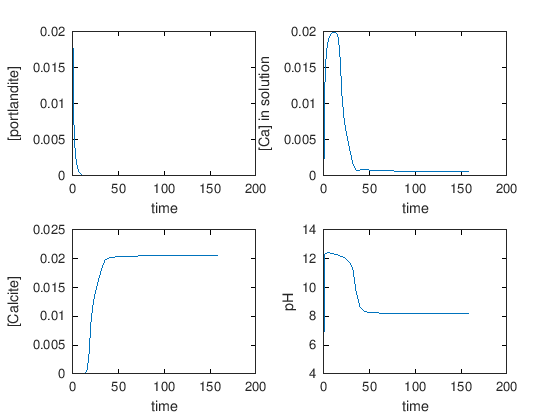

In [11]:

subplot(221); plot(time,portlanditephreeqc); ylabel('[portlandite]'); xlabel('time')
subplot(222); plot(time,Caphreeqc); ylabel('[Ca] in solution'); xlabel('time')
subplot(223); plot(time,calcitephreeqc); ylabel('[Calcite]'); xlabel('time')
subplot(224); plot(time,pHphreeqc); ylabel('pH'); xlabel('time')



In [12]:
% data
%6 g cement small size

data=[...
%Sampling times (H)	pH A	DIC A (mmol/L)	Conductivity A (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
%Sampling times (H)	pH A	DIC A (mmol/L)	Conductivity A (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	6.66	-0.25929	NaN	0.0921	0.02132
0.10	11.51	1.27546	696	2.0706	0.12482
2.00	12.03	1.48342	2322	6.1970	0.11454
24.00	10.88	0.74054	500	1.0788	0.42464
48.00	8.23	0.59821	476	1.8181	0.93536
72.00	8.05	0.89163	582	2.0152	1.45714
96.00	8.05	1.12933	617	1.9662	1.15964
144.00	8.15	1.17396	639	2.0024	1.22714
%Sampling times (H)	pH B	DIC B(mmol/L)	Conductivity B (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	6.21	-0.1027	NaN	0.0321	-0.00446
0.10	11.82	2.4275	873	2.0477	0.09664
2.00	12.13	1.3000	2330	3.2240	0.08768
24.00	10.98	2.3923	402	1.6056	0.39250
48.00	8.29	1.1862	483	1.1220	0.92750
72.00	8.19	1.0103	508	1.8858	0.87786
96.00	8.18	0.9039	557	2.1045	0.92321
144.00	8.15	1.0894	601	2.1809	0.94036
%ampling times (H)	pH C	DIC C (mmol/L)	Conductivity C (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	6.11	-0.1200	NaN	0.04033	-0.00600
0.10	11.75	2.0501	865	1.24833	2.70100
2.00	12.10	1.5490	2189	2.95400	3.00600
24.00	10.59	0.7499	357	1.29990	14.42000
48.00	8.22	0.9211	484	1.13295	25.27000
72.00	8.13	0.9955	501	1.96453	25.95000
96.00	8.14	0.81	541	2.05085	28.81000
144.00	8.14	1.04	565	2.16098	28.57000
];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);


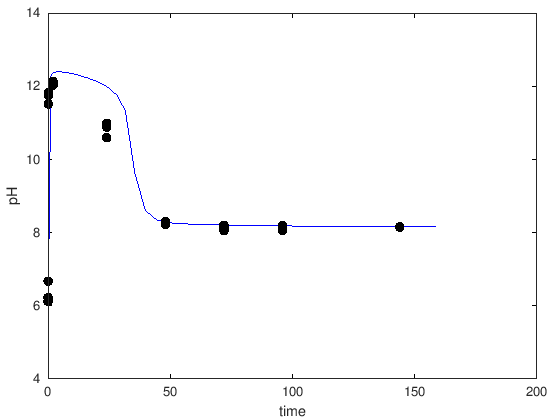

In [13]:
plot(time,pHphreeqc,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

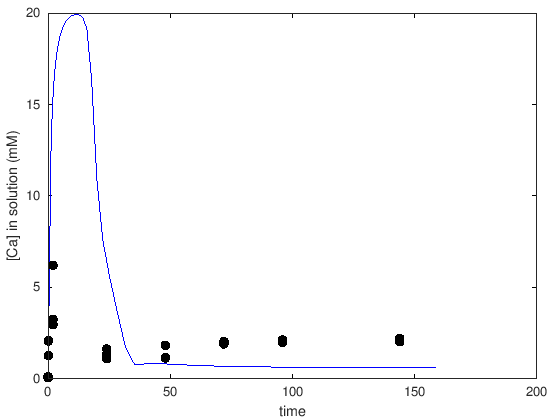

In [14]:
plot(time,(Caphreeqc*1e3),'b-','linewidth',2); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

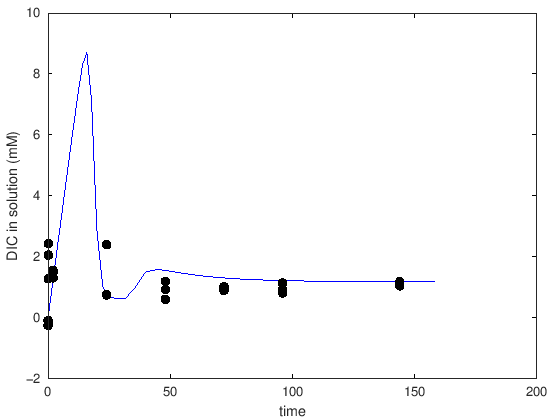

In [15]:
plot(time,1e3*DIC,'b-','linewidth',2); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

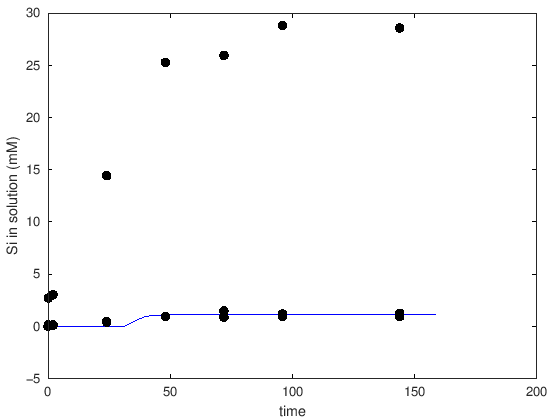

In [16]:
plot(time,1e3*(Siaq),'b-','linewidth',2); ylabel('Si in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleSi*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

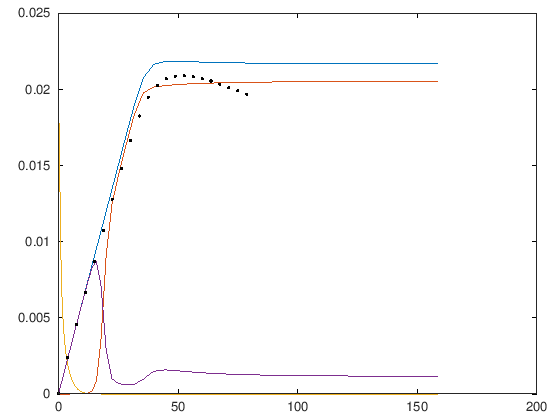

In [17]:
% plot total C that ends up in solution

CTsoln=DIC+calcitephreeqc;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcitephreeqc,time,portlanditephreeqc,time,DIC,'linewidth',2)


data=[...
%Time (min)	Time(h)	Carbon dioxide(ppm)		CO2_input (mol)	CO2_out (mol)	△ CO2 consumed (mol)	CO2 capture rate （umol/5 min）	CO2 capture rate （umol/h）	CO2 capture （umol）
3	0.05	320		5.83625E-05	3.86667E-05	0.00001969583 	19.7 	236.4 	19.7 
8	0.133333333	143		0.000058	1.72792E-05	0.00004072083 	40.7 	488.7 	60.4 
13	0.216666667	86		5.84833E-05	1.03917E-05	0.00004809167 	48.1 	577.1 	108.5 
18	0.3	68		5.81208E-05	8.21667E-06	0.00004990417 	49.9 	598.9 	158.4 
23	0.383333333	56		5.92083E-05	6.76667E-06	0.00005244167 	52.4 	629.3 	210.9 
28	0.466666667	44		6.04167E-05	5.31667E-06	0.00005510000 	55.1 	661.2 	266.0 
33	0.55	41		6.07792E-05	4.95417E-06	0.00005582500 	55.8 	669.9 	321.8 
38	0.633333333	34		6.15042E-05	4.10833E-06	0.00005739583 	57.4 	688.8 	379.2 
43	0.716666667	51		0.0000609	6.1625E-06	0.00005473750 	54.7 	656.9 	433.9 
48	0.8	41		6.05375E-05	4.95417E-06	0.00005558333 	55.6 	667.0 	489.5 
53	0.883333333	45		6.15042E-05	5.4375E-06	0.00005606667 	56.1 	672.8 	545.6 
58	0.966666667	38		6.02958E-05	4.59167E-06	0.00005570417 	55.7 	668.5 	601.3 
63	1.05	37		6.04167E-05	4.47083E-06	0.00005594583 	55.9 	671.4 	657.2 
68	1.133333333	38		5.89667E-05	4.59167E-06	0.00005437500 	54.4 	652.5 	711.6 
73	1.216666667	47		0.000058	5.67917E-06	0.00005232083 	52.3 	627.9 	763.9 
78	1.3	32		5.78792E-05	3.86667E-06	0.00005401250 	54.0 	648.2 	817.9 
83	1.383333333	32		5.77583E-05	3.86667E-06	0.00005389167 	53.9 	646.7 	871.8 
88	1.466666667	38		5.81208E-05	4.59167E-06	0.00005352917 	53.5 	642.4 	925.3 
93	1.55	32		5.76375E-05	3.86667E-06	0.00005377083 	53.8 	645.3 	979.1 
98	1.633333333	35		5.76375E-05	4.22917E-06	0.00005340833 	53.4 	640.9 	1032.5 
103	1.716666667	36		5.78792E-05	0.00000435	0.00005352917 	53.5 	642.4 	1086.1 
108	1.8	32		0.000058	3.86667E-06	0.00005413333 	54.1 	649.6 	1140.2 
113	1.883333333	29		0.000058	3.50417E-06	0.00005449583 	54.5 	654.0 	1194.7 
118	1.966666667	31		5.77583E-05	3.74583E-06	0.00005401250 	54.0 	648.2 	1248.7 
123	2.05	34		5.71542E-05	4.10833E-06	0.00005304583 	53.0 	636.6 	1301.7 
128	2.133333333	25		5.66708E-05	3.02083E-06	0.00005365000 	53.7 	643.8 	1355.4 
133	2.216666667	29		5.66708E-05	3.50417E-06	0.00005316667 	53.2 	638.0 	1408.6 
138	2.3	36		5.64292E-05	0.00000435	0.00005207917 	52.1 	625.0 	1460.6 
143	2.383333333	38		5.70333E-05	4.59167E-06	0.00005244167 	52.4 	629.3 	1513.1 
148	2.466666667	37		0.000057275	4.47083E-06	0.00005280417 	52.8 	633.7 	1565.9 
153	2.55	33		5.71542E-05	3.9875E-06	0.00005316667 	53.2 	638.0 	1619.0 
158	2.633333333	33		5.71542E-05	3.9875E-06	0.00005316667 	53.2 	638.0 	1672.2 
163	2.716666667	33		5.67917E-05	3.9875E-06	0.00005280417 	52.8 	633.7 	1725.0 
168	2.8	43		5.71542E-05	5.19583E-06	0.00005195833 	52.0 	623.5 	1777.0 
173	2.883333333	29		5.69125E-05	3.50417E-06	0.00005340833 	53.4 	640.9 	1830.4 
178	2.966666667	32		5.64292E-05	3.86667E-06	0.00005256250 	52.6 	630.8 	1882.9 
183	3.05	31		5.53417E-05	3.74583E-06	0.00005159583 	51.6 	619.2 	1934.5 
188	3.133333333	36		5.49792E-05	0.00000435	0.00005062917 	50.6 	607.6 	1985.2 
193	3.216666667	32		5.54625E-05	3.86667E-06	0.00005159583 	51.6 	619.2 	2036.8 
198	3.3	38		5.48583E-05	4.59167E-06	0.00005026667 	50.3 	603.2 	2087.0 
203	3.383333333	29		5.38917E-05	3.50417E-06	0.00005038750 	50.4 	604.7 	2137.4 
208	3.466666667	36		0.00005365	0.00000435	0.00004930000 	49.3 	591.6 	2186.7 
213	3.55	32		5.34083E-05	3.86667E-06	0.00004954167 	49.5 	594.5 	2236.3 
218	3.633333333	29		5.35292E-05	3.50417E-06	0.00005002500 	50.0 	600.3 	2286.3 
223	3.716666667	30		5.31667E-05	0.000003625	0.00004954167 	49.5 	594.5 	2335.8 
228	3.8	34		5.26833E-05	4.10833E-06	0.00004857500 	48.6 	582.9 	2384.4 
233	3.883333333	29		0.000052925	3.50417E-06	0.00004942083 	49.4 	593.1 	2433.8 
238	3.966666667	36		5.31667E-05	0.00000435	0.00004881667 	48.8 	585.8 	2482.6 
243	4.05	30		5.24417E-05	0.000003625	0.00004881667 	48.8 	585.8 	2531.5 
248	4.133333333	33		5.25625E-05	3.9875E-06	0.00004857500 	48.6 	582.9 	2580.0 
253	4.216666667	37		5.28042E-05	4.47083E-06	0.00004833333 	48.3 	580.0 	2628.4 
258	4.3	34		5.26833E-05	4.10833E-06	0.00004857500 	48.6 	582.9 	2676.9 
263	4.383333333	34		0.000052925	4.10833E-06	0.00004881667 	48.8 	585.8 	2725.8 
268	4.466666667	40		5.28042E-05	4.83333E-06	0.00004797083 	48.0 	575.7 	2773.7 
273	4.55	34		5.26833E-05	4.10833E-06	0.00004857500 	48.6 	582.9 	2822.3 
278	4.633333333	38		5.30458E-05	4.59167E-06	0.00004845417 	48.5 	581.5 	2870.8 
283	4.716666667	36		5.25625E-05	0.00000435	0.00004821250 	48.2 	578.6 	2919.0 
288	4.8	36		0.000052925	0.00000435	0.00004857500 	48.6 	582.9 	2967.5 
293	4.883333333	37		5.32875E-05	4.47083E-06	0.00004881667 	48.8 	585.8 	3016.4 
298	4.966666667	40		5.26833E-05	4.83333E-06	0.00004785000 	47.9 	574.2 	3064.2 
303	5.05	30		5.30458E-05	0.000003625	0.00004942083 	49.4 	593.1 	3113.6 
308	5.133333333	32		5.28042E-05	3.86667E-06	0.00004893750 	48.9 	587.3 	3162.6 
313	5.216666667	35		5.25625E-05	4.22917E-06	0.00004833333 	48.3 	580.0 	3210.9 
318	5.3	35		5.28042E-05	4.22917E-06	0.00004857500 	48.6 	582.9 	3259.5 
323	5.383333333	36		5.25625E-05	0.00000435	0.00004821250 	48.2 	578.6 	3307.7 
328	5.466666667	38		5.23208E-05	4.59167E-06	0.00004772917 	47.7 	572.8 	3355.4 
333	5.55	35		5.25625E-05	4.22917E-06	0.00004833333 	48.3 	580.0 	3403.8 
338	5.633333333	35		5.26833E-05	4.22917E-06	0.00004845417 	48.5 	581.5 	3452.2 
343	5.716666667	42		5.25625E-05	0.000005075	0.00004748750 	47.5 	569.9 	3499.7 
348	5.8	42		5.25625E-05	0.000005075	0.00004748750 	47.5 	569.9 	3547.2 
353	5.883333333	42		0.0000522	0.000005075	0.00004712500 	47.1 	565.5 	3594.3 
358	5.966666667	35		5.26833E-05	4.22917E-06	0.00004845417 	48.5 	581.5 	3642.8 
363	6.05	36		5.24417E-05	0.00000435	0.00004809167 	48.1 	577.1 	3690.9 
368	6.133333333	32		5.25625E-05	3.86667E-06	0.00004869583 	48.7 	584.4 	3739.6 
373	6.216666667	35		5.26833E-05	4.22917E-06	0.00004845417 	48.5 	581.5 	3788.0 
378	6.3	32		5.28042E-05	3.86667E-06	0.00004893750 	48.9 	587.3 	3836.9 
383	6.383333333	32		5.24417E-05	3.86667E-06	0.00004857500 	48.6 	582.9 	3885.5 
388	6.466666667	45		5.19583E-05	5.4375E-06	0.00004652083 	46.5 	558.3 	3932.0 
393	6.55	37		5.25625E-05	4.47083E-06	0.00004809167 	48.1 	577.1 	3980.1 
398	6.633333333	24		5.20792E-05	0.0000029	0.00004917917 	49.2 	590.2 	4029.3 
403	6.716666667	37		5.24417E-05	4.47083E-06	0.00004797083 	48.0 	575.7 	4077.3 
408	6.8	40		5.19583E-05	4.83333E-06	0.00004712500 	47.1 	565.5 	4124.4 
413	6.883333333	47		5.18375E-05	5.67917E-06	0.00004615833 	46.2 	553.9 	4170.6 
418	6.966666667	43		0.0000522	5.19583E-06	0.00004700417 	47.0 	564.1 	4217.6 
423	7.05	35		0.0000522	4.22917E-06	0.00004797083 	48.0 	575.7 	4265.5 
428	7.133333333	40		5.24417E-05	4.83333E-06	0.00004760833 	47.6 	571.3 	4313.1 
433	7.216666667	43		0.0000522	5.19583E-06	0.00004700417 	47.0 	564.1 	4360.2 
438	7.3	40		5.23208E-05	4.83333E-06	0.00004748750 	47.5 	569.9 	4407.6 
443	7.383333333	48		5.19583E-05	0.0000058	0.00004615833 	46.2 	553.9 	4453.8 
448	7.466666667	44		0.0000522	5.31667E-06	0.00004688333 	46.9 	562.6 	4500.7 
453	7.55	49		5.20792E-05	5.92083E-06	0.00004615833 	46.2 	553.9 	4546.8 
458	7.633333333	45		5.25625E-05	5.4375E-06	0.00004712500 	47.1 	565.5 	4594.0 
463	7.716666667	49		5.19583E-05	5.92083E-06	0.00004603750 	46.0 	552.5 	4640.0 
468	7.8	42		0.0000522	0.000005075	0.00004712500 	47.1 	565.5 	4687.1 
473	7.883333333	45		0.0000522	5.4375E-06	0.00004676250 	46.8 	561.2 	4733.9 
478	7.966666667	35		5.23208E-05	4.22917E-06	0.00004809167 	48.1 	577.1 	4782.0 
483	8.05	42		5.20792E-05	0.000005075	0.00004700417 	47.0 	564.1 	4829.0 
488	8.133333333	51		5.23208E-05	6.1625E-06	0.00004615833 	46.2 	553.9 	4875.1 
493	8.216666667	44		5.19583E-05	5.31667E-06	0.00004664167 	46.6 	559.7 	4921.8 
498	8.3	39		5.24417E-05	4.7125E-06	0.00004772917 	47.7 	572.8 	4969.5 
503	8.383333333	40		5.18375E-05	4.83333E-06	0.00004700417 	47.0 	564.1 	5016.5 
508	8.466666667	40		5.19583E-05	4.83333E-06	0.00004712500 	47.1 	565.5 	5063.6 
513	8.55	47		5.20792E-05	5.67917E-06	0.00004640000 	46.4 	556.8 	5110.0 
518	8.633333333	48		5.26833E-05	0.0000058	0.00004688333 	46.9 	562.6 	5156.9 
523	8.716666667	46		0.0000522	5.55833E-06	0.00004664167 	46.6 	559.7 	5203.6 
528	8.8	52		5.23208E-05	6.28333E-06	0.00004603750 	46.0 	552.5 	5249.6 
533	8.883333333	49		5.26833E-05	5.92083E-06	0.00004676250 	46.8 	561.2 	5296.4 
538	8.966666667	47		5.18375E-05	5.67917E-06	0.00004615833 	46.2 	553.9 	5342.5 
543	9.05	49		5.25625E-05	5.92083E-06	0.00004664167 	46.6 	559.7 	5389.2 
548	9.133333333	51		5.24417E-05	6.1625E-06	0.00004627917 	46.3 	555.4 	5435.4 
553	9.216666667	50		5.23208E-05	6.04167E-06	0.00004627917 	46.3 	555.4 	5481.7 
558	9.3	50		5.23208E-05	6.04167E-06	0.00004627917 	46.3 	555.4 	5528.0 
563	9.383333333	48		5.24417E-05	0.0000058	0.00004664167 	46.6 	559.7 	5574.6 
568	9.466666667	55		5.24417E-05	6.64583E-06	0.00004579583 	45.8 	549.6 	5620.4 
573	9.55	47		5.24417E-05	5.67917E-06	0.00004676250 	46.8 	561.2 	5667.2 
578	9.633333333	46		5.23208E-05	5.55833E-06	0.00004676250 	46.8 	561.2 	5714.0 
583	9.716666667	48		5.24417E-05	0.0000058	0.00004664167 	46.6 	559.7 	5760.6 
588	9.8	52		5.28042E-05	6.28333E-06	0.00004652083 	46.5 	558.3 	5807.1 
593	9.883333333	52		5.26833E-05	6.28333E-06	0.00004640000 	46.4 	556.8 	5853.5 
598	9.966666667	52		5.24417E-05	6.28333E-06	0.00004615833 	46.2 	553.9 	5899.7 
603	10.05	51		5.30458E-05	6.1625E-06	0.00004688333 	46.9 	562.6 	5946.6 
608	10.13333333	54		0.000052925	0.000006525	0.00004640000 	46.4 	556.8 	5993.0 
613	10.21666667	53		5.31667E-05	6.40417E-06	0.00004676250 	46.8 	561.2 	6039.7 
618	10.3	60		5.28042E-05	0.00000725	0.00004555417 	45.6 	546.7 	6085.3 
623	10.38333333	59		5.32875E-05	7.12917E-06	0.00004615833 	46.2 	553.9 	6131.4 
628	10.46666667	55		5.34083E-05	6.64583E-06	0.00004676250 	46.8 	561.2 	6178.2 
633	10.55	58		5.34083E-05	7.00833E-06	0.00004640000 	46.4 	556.8 	6224.6 
638	10.63333333	52		5.30458E-05	6.28333E-06	0.00004676250 	46.8 	561.2 	6271.4 
643	10.71666667	61		5.30458E-05	7.37083E-06	0.00004567500 	45.7 	548.1 	6317.0 
648	10.8	51		0.00005365	6.1625E-06	0.00004748750 	47.5 	569.9 	6364.5 
653	10.88333333	52		5.34083E-05	6.28333E-06	0.00004712500 	47.1 	565.5 	6411.7 
658	10.96666667	60		5.32875E-05	0.00000725	0.00004603750 	46.0 	552.5 	6457.7 
663	11.05	56		5.34083E-05	6.76667E-06	0.00004664167 	46.6 	559.7 	6504.3 
668	11.13333333	47		5.34083E-05	5.67917E-06	0.00004772917 	47.7 	572.8 	6552.1 
673	11.21666667	63		5.31667E-05	7.6125E-06	0.00004555417 	45.6 	546.7 	6597.6 
678	11.3	61		5.37708E-05	7.37083E-06	0.00004640000 	46.4 	556.8 	6644.0 
683	11.38333333	59		5.35292E-05	7.12917E-06	0.00004640000 	46.4 	556.8 	6690.4 
688	11.46666667	57		5.34083E-05	6.8875E-06	0.00004652083 	46.5 	558.3 	6736.9 
693	11.55	63		5.35292E-05	7.6125E-06	0.00004591667 	45.9 	551.0 	6782.9 
698	11.63333333	63		0.000052925	7.6125E-06	0.00004531250 	45.3 	543.8 	6828.2 
703	11.71666667	58		5.30458E-05	7.00833E-06	0.00004603750 	46.0 	552.5 	6874.2 
708	11.8	59		5.31667E-05	7.12917E-06	0.00004603750 	46.0 	552.5 	6920.2 
713	11.88333333	62		5.35292E-05	7.49167E-06	0.00004603750 	46.0 	552.5 	6966.3 
718	11.96666667	62		5.34083E-05	7.49167E-06	0.00004591667 	45.9 	551.0 	7012.2 
723	12.05	65		5.31667E-05	7.85417E-06	0.00004531250 	45.3 	543.8 	7057.5 
728	12.13333333	63		5.30458E-05	7.6125E-06	0.00004543333 	45.4 	545.2 	7102.9 
733	12.21666667	64		0.00005365	7.73333E-06	0.00004591667 	45.9 	551.0 	7148.9 
738	12.3	69		5.34083E-05	8.3375E-06	0.00004507083 	45.1 	540.9 	7193.9 
743	12.38333333	52		0.000052925	6.28333E-06	0.00004664167 	46.6 	559.7 	7240.6 
748	12.46666667	62		5.30458E-05	7.49167E-06	0.00004555417 	45.6 	546.7 	7286.1 
753	12.55	65		5.31667E-05	7.85417E-06	0.00004531250 	45.3 	543.8 	7331.4 
758	12.63333333	62		5.30458E-05	7.49167E-06	0.00004555417 	45.6 	546.7 	7377.0 
763	12.71666667	63		5.26833E-05	7.6125E-06	0.00004507083 	45.1 	540.9 	7422.1 
768	12.8	62		5.24417E-05	7.49167E-06	0.00004495000 	45.0 	539.4 	7467.0 
773	12.88333333	68		5.26833E-05	8.21667E-06	0.00004446667 	44.5 	533.6 	7511.5 
778	12.96666667	60		5.31667E-05	0.00000725	0.00004591667 	45.9 	551.0 	7557.4 
783	13.05	61		0.000052925	7.37083E-06	0.00004555417 	45.6 	546.7 	7603.0 
788	13.13333333	64		5.28042E-05	7.73333E-06	0.00004507083 	45.1 	540.9 	7648.0 
793	13.21666667	61		5.26833E-05	7.37083E-06	0.00004531250 	45.3 	543.8 	7693.3 
798	13.3	63		5.30458E-05	7.6125E-06	0.00004543333 	45.4 	545.2 	7738.8 
803	13.38333333	68		0.000052925	8.21667E-06	0.00004470833 	44.7 	536.5 	7783.5 
808	13.46666667	61		5.26833E-05	7.37083E-06	0.00004531250 	45.3 	543.8 	7828.8 
813	13.55	62		0.000052925	7.49167E-06	0.00004543333 	45.4 	545.2 	7874.2 
818	13.63333333	70		0.000052925	8.45833E-06	0.00004446667 	44.5 	533.6 	7918.7 
823	13.71666667	61		5.30458E-05	7.37083E-06	0.00004567500 	45.7 	548.1 	7964.4 
828	13.8	60		5.25625E-05	0.00000725	0.00004531250 	45.3 	543.8 	8009.7 
833	13.88333333	75		5.26833E-05	9.0625E-06	0.00004362083 	43.6 	523.5 	8053.3 
838	13.96666667	65		5.25625E-05	7.85417E-06	0.00004470833 	44.7 	536.5 	8098.0 
843	14.05	62		0.000052925	7.49167E-06	0.00004543333 	45.4 	545.2 	8143.4 
848	14.13333333	70		5.32875E-05	8.45833E-06	0.00004482917 	44.8 	538.0 	8188.3 
853	14.21666667	65		5.32875E-05	7.85417E-06	0.00004543333 	45.4 	545.2 	8233.7 
858	14.3	62		5.32875E-05	7.49167E-06	0.00004579583 	45.8 	549.6 	8279.5 
863	14.38333333	65		5.31667E-05	7.85417E-06	0.00004531250 	45.3 	543.8 	8324.8 
868	14.46666667	59		5.31667E-05	7.12917E-06	0.00004603750 	46.0 	552.5 	8370.9 
873	14.55	67		5.30458E-05	8.09583E-06	0.00004495000 	45.0 	539.4 	8415.8 
878	14.63333333	68		5.25625E-05	8.21667E-06	0.00004434583 	44.3 	532.2 	8460.1 
883	14.71666667	68		5.26833E-05	8.21667E-06	0.00004446667 	44.5 	533.6 	8504.6 
888	14.8	67		5.30458E-05	8.09583E-06	0.00004495000 	45.0 	539.4 	8549.6 
893	14.88333333	62		5.30458E-05	7.49167E-06	0.00004555417 	45.6 	546.7 	8595.1 
898	14.96666667	54		5.35292E-05	0.000006525	0.00004700417 	47.0 	564.1 	8642.1 
903	15.05	72		5.30458E-05	0.0000087	0.00004434583 	44.3 	532.2 	8686.5 
908	15.13333333	66		0.000052925	0.000007975	0.00004495000 	45.0 	539.4 	8731.4 
913	15.21666667	66		5.34083E-05	0.000007975	0.00004543333 	45.4 	545.2 	8776.9 
918	15.3	70		5.30458E-05	8.45833E-06	0.00004458750 	44.6 	535.1 	8821.4 
923	15.38333333	76		5.32875E-05	9.18333E-06	0.00004410417 	44.1 	529.3 	8865.5 
928	15.46666667	74		0.000052925	8.94167E-06	0.00004398333 	44.0 	527.8 	8909.5 
933	15.55	74		5.30458E-05	8.94167E-06	0.00004410417 	44.1 	529.3 	8953.6 
938	15.63333333	74		5.30458E-05	8.94167E-06	0.00004410417 	44.1 	529.3 	8997.7 
943	15.71666667	74		5.34083E-05	8.94167E-06	0.00004446667 	44.5 	533.6 	9042.2 
948	15.8	68		0.00005365	8.21667E-06	0.00004543333 	45.4 	545.2 	9087.6 
953	15.88333333	76		5.35292E-05	9.18333E-06	0.00004434583 	44.3 	532.2 	9132.0 
958	15.96666667	73		5.37708E-05	8.82083E-06	0.00004495000 	45.0 	539.4 	9176.9 
963	16.05	82		5.40125E-05	9.90833E-06	0.00004410417 	44.1 	529.3 	9221.0 
968	16.13333333	71		5.37708E-05	8.57917E-06	0.00004519167 	45.2 	542.3 	9266.2 
973	16.21666667	77		5.40125E-05	9.30417E-06	0.00004470833 	44.7 	536.5 	9310.9 
978	16.3	85		5.40125E-05	1.02708E-05	0.00004374167 	43.7 	524.9 	9354.7 
983	16.38333333	75		5.42542E-05	9.0625E-06	0.00004519167 	45.2 	542.3 	9399.9 
988	16.46666667	74		0.00005365	8.94167E-06	0.00004470833 	44.7 	536.5 	9444.6 
993	16.55	69		0.00005365	8.3375E-06	0.00004531250 	45.3 	543.8 	9489.9 
998	16.63333333	80		0.000054375	9.66667E-06	0.00004470833 	44.7 	536.5 	9534.6 
1003	16.71666667	79		5.46167E-05	9.54583E-06	0.00004507083 	45.1 	540.9 	9579.7 
1008	16.8	74		5.42542E-05	8.94167E-06	0.00004531250 	45.3 	543.8 	9625.0 
1013	16.88333333	84		5.47375E-05	0.00001015	0.00004458750 	44.6 	535.1 	9669.6 
1018	16.96666667	80		5.40125E-05	9.66667E-06	0.00004434583 	44.3 	532.2 	9713.9 
1023	17.05	76		5.48583E-05	9.18333E-06	0.00004567500 	45.7 	548.1 	9759.6 
1028	17.13333333	81		5.41333E-05	9.7875E-06	0.00004434583 	44.3 	532.2 	9803.9 
1033	17.21666667	85		5.44958E-05	1.02708E-05	0.00004422500 	44.2 	530.7 	9848.2 
1038	17.3	84		5.46167E-05	0.00001015	0.00004446667 	44.5 	533.6 	9892.6 
1043	17.38333333	82		5.52208E-05	9.90833E-06	0.00004531250 	45.3 	543.8 	9937.9 
1048	17.46666667	81		0.0000551	9.7875E-06	0.00004531250 	45.3 	543.8 	9983.3 
1053	17.55	84		5.49792E-05	0.00001015	0.00004482917 	44.8 	538.0 	10028.1 
1058	17.63333333	85		5.52208E-05	1.02708E-05	0.00004495000 	45.0 	539.4 	10073.0 
1063	17.71666667	82		5.47375E-05	9.90833E-06	0.00004482917 	44.8 	538.0 	10117.9 
1068	17.8	82		0.000055825	9.90833E-06	0.00004591667 	45.9 	551.0 	10163.8 
1073	17.88333333	83		0.000055825	1.00292E-05	0.00004579583 	45.8 	549.6 	10209.6 
1078	17.96666667	74		5.57042E-05	8.94167E-06	0.00004676250 	46.8 	561.2 	10256.3 
1083	18.05	85		5.59458E-05	1.02708E-05	0.00004567500 	45.7 	548.1 	10302.0 
1088	18.13333333	79		5.61875E-05	9.54583E-06	0.00004664167 	46.6 	559.7 	10348.7 
1093	18.21666667	78		5.57042E-05	0.000009425	0.00004627917 	46.3 	555.4 	10394.9 
1098	18.3	83		5.57042E-05	1.00292E-05	0.00004567500 	45.7 	548.1 	10440.6 
1103	18.38333333	86		5.53417E-05	1.03917E-05	0.00004495000 	45.0 	539.4 	10485.6 
1108	18.46666667	90		5.53417E-05	0.000010875	0.00004446667 	44.5 	533.6 	10530.0 
1113	18.55	77		5.49792E-05	9.30417E-06	0.00004567500 	45.7 	548.1 	10575.7 
1118	18.63333333	88		5.52208E-05	1.06333E-05	0.00004458750 	44.6 	535.1 	10620.3 
1123	18.71666667	84		5.52208E-05	0.00001015	0.00004507083 	45.1 	540.9 	10665.4 
1128	18.8	82		0.000055825	9.90833E-06	0.00004591667 	45.9 	551.0 	10711.3 
1133	18.88333333	86		0.000055825	1.03917E-05	0.00004543333 	45.4 	545.2 	10756.7 
1138	18.96666667	94		5.53417E-05	1.13583E-05	0.00004398333 	44.0 	527.8 	10800.7 
1143	19.05	88		0.000055825	1.06333E-05	0.00004519167 	45.2 	542.3 	10845.9 
1148	19.13333333	88		5.60667E-05	1.06333E-05	0.00004543333 	45.4 	545.2 	10891.3 
1153	19.21666667	84		0.00005655	0.00001015	0.00004640000 	46.4 	556.8 	10937.7 
1158	19.3	78		5.64292E-05	0.000009425	0.00004700417 	47.0 	564.1 	10984.7 
1163	19.38333333	95		5.66708E-05	1.14792E-05	0.00004519167 	45.2 	542.3 	11029.9 
1168	19.46666667	89		5.77583E-05	1.07542E-05	0.00004700417 	47.0 	564.1 	11076.9 
1173	19.55	87		5.81208E-05	1.05125E-05	0.00004760833 	47.6 	571.3 	11124.5 
1178	19.63333333	90		5.77583E-05	0.000010875	0.00004688333 	46.9 	562.6 	11171.4 
1183	19.71666667	96		5.81208E-05	0.0000116	0.00004652083 	46.5 	558.3 	11217.9 
1188	19.8	91		5.83625E-05	1.09958E-05	0.00004736667 	47.4 	568.4 	11265.3 
1193	19.88333333	97		5.84833E-05	1.17208E-05	0.00004676250 	46.8 	561.2 	11312.1 
1198	19.96666667	99		5.88458E-05	1.19625E-05	0.00004688333 	46.9 	562.6 	11358.9 
1203	20.05	104		5.81208E-05	1.25667E-05	0.00004555417 	45.6 	546.7 	11404.5 
1208	20.13333333	112		5.84833E-05	1.35333E-05	0.00004495000 	45.0 	539.4 	11449.4 
1213	20.21666667	95		5.81208E-05	1.14792E-05	0.00004664167 	46.6 	559.7 	11496.1 
1218	20.3	101		5.82417E-05	1.22042E-05	0.00004603750 	46.0 	552.5 	11542.1 
1223	20.38333333	95		0.000058	1.14792E-05	0.00004652083 	46.5 	558.3 	11588.6 
1228	20.46666667	102		5.81208E-05	0.000012325	0.00004579583 	45.8 	549.6 	11634.4 
1233	20.55	102		0.000060175	0.000012325	0.00004785000 	47.9 	574.2 	11682.3 
1238	20.63333333	104		6.04167E-05	1.25667E-05	0.00004785000 	47.9 	574.2 	11730.1 
1243	20.71666667	95		5.99333E-05	1.14792E-05	0.00004845417 	48.5 	581.5 	11778.6 
1248	20.8	96		0.00005945	0.0000116	0.00004785000 	47.9 	574.2 	11826.4 
1253	20.88333333	94		5.96917E-05	1.13583E-05	0.00004833333 	48.3 	580.0 	11874.8 
1258	20.96666667	95		0.0000609	1.14792E-05	0.00004942083 	49.4 	593.1 	11924.2 
1263	21.05	104		6.05375E-05	1.25667E-05	0.00004797083 	48.0 	575.7 	11972.2 
1268	21.13333333	100		5.93292E-05	1.20833E-05	0.00004724583 	47.2 	567.0 	12019.4 
1273	21.21666667	108		5.83625E-05	0.00001305	0.00004531250 	45.3 	543.8 	12064.7 
1278	21.3	104		5.82417E-05	1.25667E-05	0.00004567500 	45.7 	548.1 	12110.4 
1283	21.38333333	98		5.86042E-05	1.18417E-05	0.00004676250 	46.8 	561.2 	12157.2 
1288	21.46666667	103		5.90875E-05	1.24458E-05	0.00004664167 	46.6 	559.7 	12203.8 
1293	21.55	104		5.82417E-05	1.25667E-05	0.00004567500 	45.7 	548.1 	12249.5 
1298	21.63333333	99		0.000058725	1.19625E-05	0.00004676250 	46.8 	561.2 	12296.2 
1303	21.71666667	101		5.77583E-05	1.22042E-05	0.00004555417 	45.6 	546.7 	12341.8 
1308	21.8	91		5.70333E-05	1.09958E-05	0.00004603750 	46.0 	552.5 	12387.8 
1313	21.88333333	92		5.66708E-05	1.11167E-05	0.00004555417 	45.6 	546.7 	12433.4 
1318	21.96666667	102		5.67917E-05	0.000012325	0.00004446667 	44.5 	533.6 	12477.9 
1323	22.05	101		0.00005655	1.22042E-05	0.00004434583 	44.3 	532.2 	12522.2 
1328	22.13333333	98		5.70333E-05	1.18417E-05	0.00004519167 	45.2 	542.3 	12567.4 
1333	22.21666667	102		0.00005655	0.000012325	0.00004422500 	44.2 	530.7 	12611.6 
1338	22.3	104		5.67917E-05	1.25667E-05	0.00004422500 	44.2 	530.7 	12655.8 
1343	22.38333333	104		5.70333E-05	1.25667E-05	0.00004446667 	44.5 	533.6 	12700.3 
1348	22.46666667	103		5.70333E-05	1.24458E-05	0.00004458750 	44.6 	535.1 	12744.9 
1353	22.55	111		5.71542E-05	1.34125E-05	0.00004374167 	43.7 	524.9 	12788.6 
1358	22.63333333	106		5.69125E-05	1.28083E-05	0.00004410417 	44.1 	529.3 	12832.7 
1363	22.71666667	105		0.000057275	1.26875E-05	0.00004458750 	44.6 	535.1 	12877.3 
1368	22.8	105		5.73958E-05	1.26875E-05	0.00004470833 	44.7 	536.5 	12922.0 
1373	22.88333333	104		5.67917E-05	1.25667E-05	0.00004422500 	44.2 	530.7 	12966.3 
1378	22.96666667	102		5.63083E-05	0.000012325	0.00004398333 	44.0 	527.8 	13010.2 
1383	23.05	106		5.64292E-05	1.28083E-05	0.00004362083 	43.6 	523.5 	13053.9 
1388	23.13333333	97		5.70333E-05	1.17208E-05	0.00004531250 	45.3 	543.8 	13099.2 
1393	23.21666667	106		0.00005655	1.28083E-05	0.00004374167 	43.7 	524.9 	13142.9 
1398	23.3	99		5.60667E-05	1.19625E-05	0.00004410417 	44.1 	529.3 	13187.0 
1403	23.38333333	102		5.59458E-05	0.000012325	0.00004362083 	43.6 	523.5 	13230.6 
1408	23.46666667	106		0.000057275	1.28083E-05	0.00004446667 	44.5 	533.6 	13275.1 
1413	23.55	108		5.71542E-05	0.00001305	0.00004410417 	44.1 	529.3 	13319.2 
1418	23.63333333	101		5.69125E-05	1.22042E-05	0.00004470833 	44.7 	536.5 	13363.9 
1423	23.71666667	105		5.73958E-05	1.26875E-05	0.00004470833 	44.7 	536.5 	13408.6 
1428	23.8	107		5.67917E-05	1.29292E-05	0.00004386250 	43.9 	526.4 	13452.5 
1433	23.88333333	113		5.71542E-05	1.36542E-05	0.00004350000 	43.5 	522.0 	13496.0 
1438	23.96666667	107		5.76375E-05	1.29292E-05	0.00004470833 	44.7 	536.5 	13540.7 
1443	24.05	108		0.000057275	0.00001305	0.00004422500 	44.2 	530.7 	13584.9 
1448	24.13333333	113		5.66708E-05	1.36542E-05	0.00004301667 	43.0 	516.2 	13627.9 
1453	24.21666667	110		5.69125E-05	1.32917E-05	0.00004362083 	43.6 	523.5 	13671.6 
1458	24.3	110		0.000057275	1.32917E-05	0.00004398333 	44.0 	527.8 	13715.6 
1463	24.38333333	113		5.83625E-05	1.36542E-05	0.00004470833 	44.7 	536.5 	13760.3 
1468	24.46666667	118		5.88458E-05	1.42583E-05	0.00004458750 	44.6 	535.1 	13804.8 
1473	24.55	113		5.83625E-05	1.36542E-05	0.00004470833 	44.7 	536.5 	13849.6 
1478	24.63333333	110		5.90875E-05	1.32917E-05	0.00004579583 	45.8 	549.6 	13895.4 
1483	24.71666667	111		5.82417E-05	1.34125E-05	0.00004482917 	44.8 	538.0 	13940.2 
1488	24.8	114		5.76375E-05	0.000013775	0.00004386250 	43.9 	526.4 	13984.0 
1493	24.88333333	112		5.75167E-05	1.35333E-05	0.00004398333 	44.0 	527.8 	14028.0 
1498	24.96666667	112		5.76375E-05	1.35333E-05	0.00004410417 	44.1 	529.3 	14072.1 
1503	25.05	115		5.75167E-05	1.38958E-05	0.00004362083 	43.6 	523.5 	14115.8 
1508	25.13333333	111		5.78792E-05	1.34125E-05	0.00004446667 	44.5 	533.6 	14160.2 
1513	25.21666667	109		5.78792E-05	1.31708E-05	0.00004470833 	44.7 	536.5 	14204.9 
1518	25.3	112		5.77583E-05	1.35333E-05	0.00004422500 	44.2 	530.7 	14249.2 
1523	25.38333333	113		5.76375E-05	1.36542E-05	0.00004398333 	44.0 	527.8 	14293.1 
1528	25.46666667	109		5.81208E-05	1.31708E-05	0.00004495000 	45.0 	539.4 	14338.1 
1533	25.55	115		5.81208E-05	1.38958E-05	0.00004422500 	44.2 	530.7 	14382.3 
1538	25.63333333	124		5.78792E-05	1.49833E-05	0.00004289583 	42.9 	514.8 	14425.2 
1543	25.71666667	116		0.000058	1.40167E-05	0.00004398333 	44.0 	527.8 	14469.2 
1548	25.8	124		0.000058725	1.49833E-05	0.00004374167 	43.7 	524.9 	14512.9 
1553	25.88333333	118		6.02958E-05	1.42583E-05	0.00004603750 	46.0 	552.5 	14559.0 
1558	25.96666667	112		6.10208E-05	1.35333E-05	0.00004748750 	47.5 	569.9 	14606.5 
1563	26.05	103		6.04167E-05	1.24458E-05	0.00004797083 	48.0 	575.7 	14654.4 
1568	26.13333333	111		6.04167E-05	1.34125E-05	0.00004700417 	47.0 	564.1 	14701.4 
1573	26.21666667	118		6.04167E-05	1.42583E-05	0.00004615833 	46.2 	553.9 	14747.6 
1578	26.3	116		5.98125E-05	1.40167E-05	0.00004579583 	45.8 	549.6 	14793.4 
1583	26.38333333	112		5.96917E-05	1.35333E-05	0.00004615833 	46.2 	553.9 	14839.5 
1588	26.46666667	109		5.76375E-05	1.31708E-05	0.00004446667 	44.5 	533.6 	14884.0 
1593	26.55	115		5.67917E-05	1.38958E-05	0.00004289583 	42.9 	514.8 	14926.9 
1598	26.63333333	122		5.61875E-05	1.47417E-05	0.00004144583 	41.4 	497.4 	14968.4 
1603	26.71666667	111		5.66708E-05	1.34125E-05	0.00004325833 	43.3 	519.1 	15011.6 
1608	26.8	123		5.67917E-05	1.48625E-05	0.00004192917 	41.9 	503.2 	15053.5 
1613	26.88333333	120		5.69125E-05	0.0000145	0.00004241250 	42.4 	509.0 	15096.0 
1618	26.96666667	110		5.60667E-05	1.32917E-05	0.00004277500 	42.8 	513.3 	15138.7 
1623	27.05	111		5.64292E-05	1.34125E-05	0.00004301667 	43.0 	516.2 	15181.7 
1628	27.13333333	111		5.64292E-05	1.34125E-05	0.00004301667 	43.0 	516.2 	15224.8 
1633	27.21666667	108		5.61875E-05	0.00001305	0.00004313750 	43.1 	517.7 	15267.9 
1638	27.3	106		5.70333E-05	1.28083E-05	0.00004422500 	44.2 	530.7 	15312.1 
1643	27.38333333	122		5.77583E-05	1.47417E-05	0.00004301667 	43.0 	516.2 	15355.1 
1648	27.46666667	106		0.000055825	1.28083E-05	0.00004301667 	43.0 	516.2 	15398.2 
1653	27.55	106		5.47375E-05	1.28083E-05	0.00004192917 	41.9 	503.2 	15440.1 
1658	27.63333333	116		5.41333E-05	1.40167E-05	0.00004011667 	40.1 	481.4 	15480.2 
1663	27.71666667	106		5.41333E-05	1.28083E-05	0.00004132500 	41.3 	495.9 	15521.5 
1668	27.8	117		5.41333E-05	1.41375E-05	0.00003999583 	40.0 	480.0 	15561.5 
1673	27.88333333	112		0.00005365	1.35333E-05	0.00004011667 	40.1 	481.4 	15601.6 
1678	27.96666667	110		5.35292E-05	1.32917E-05	0.00004023750 	40.2 	482.9 	15641.9 
1683	28.05	109		5.35292E-05	1.31708E-05	0.00004035833 	40.4 	484.3 	15682.2 
1688	28.13333333	110		5.35292E-05	1.32917E-05	0.00004023750 	40.2 	482.9 	15722.5 
1693	28.21666667	119		5.35292E-05	1.43792E-05	0.00003915000 	39.2 	469.8 	15761.6 
1698	28.3	114		5.37708E-05	0.000013775	0.00003999583 	40.0 	480.0 	15801.6 
1703	28.38333333	121		5.41333E-05	1.46208E-05	0.00003951250 	39.5 	474.2 	15841.1 
1708	28.46666667	112		5.38917E-05	1.35333E-05	0.00004035833 	40.4 	484.3 	15881.5 
1713	28.55	115		5.37708E-05	1.38958E-05	0.00003987500 	39.9 	478.5 	15921.4 
1718	28.63333333	113		5.38917E-05	1.36542E-05	0.00004023750 	40.2 	482.9 	15961.6 
1723	28.71666667	119		5.32875E-05	1.43792E-05	0.00003890833 	38.9 	466.9 	16000.5 
1728	28.8	114		5.32875E-05	0.000013775	0.00003951250 	39.5 	474.2 	16040.0 
1733	28.88333333	114		0.00005365	0.000013775	0.00003987500 	39.9 	478.5 	16079.9 
1738	28.96666667	117		5.42542E-05	1.41375E-05	0.00004011667 	40.1 	481.4 	16120.0 
1743	29.05	129		5.38917E-05	1.55875E-05	0.00003830417 	38.3 	459.7 	16158.3 
1748	29.13333333	121		5.41333E-05	1.46208E-05	0.00003951250 	39.5 	474.2 	16197.8 
1753	29.21666667	126		5.38917E-05	0.000015225	0.00003866667 	38.7 	464.0 	16236.5 
1758	29.3	123		5.32875E-05	1.48625E-05	0.00003842500 	38.4 	461.1 	16274.9 
1763	29.38333333	112		5.32875E-05	1.35333E-05	0.00003975417 	39.8 	477.1 	16314.7 
1768	29.46666667	123		5.31667E-05	1.48625E-05	0.00003830417 	38.3 	459.7 	16353.0 
1773	29.55	126		5.38917E-05	0.000015225	0.00003866667 	38.7 	464.0 	16391.6 
1778	29.63333333	125		5.38917E-05	1.51042E-05	0.00003878750 	38.8 	465.5 	16430.4 
1783	29.71666667	120		5.34083E-05	0.0000145	0.00003890833 	38.9 	466.9 	16469.3 
1788	29.8	123		5.31667E-05	1.48625E-05	0.00003830417 	38.3 	459.7 	16507.6 
1793	29.88333333	120		5.34083E-05	0.0000145	0.00003890833 	38.9 	466.9 	16546.6 
1798	29.96666667	126		5.32875E-05	0.000015225	0.00003806250 	38.1 	456.8 	16584.6 
1803	30.05	120		0.00005365	0.0000145	0.00003915000 	39.2 	469.8 	16623.8 
1808	30.13333333	122		0.00005365	1.47417E-05	0.00003890833 	38.9 	466.9 	16662.7 
1813	30.21666667	122		0.000052925	1.47417E-05	0.00003818333 	38.2 	458.2 	16700.9 
1818	30.3	127		5.35292E-05	1.53458E-05	0.00003818333 	38.2 	458.2 	16739.0 
1823	30.38333333	126		5.34083E-05	0.000015225	0.00003818333 	38.2 	458.2 	16777.2 
1828	30.46666667	128		5.35292E-05	1.54667E-05	0.00003806250 	38.1 	456.8 	16815.3 
1833	30.55	129		5.34083E-05	1.55875E-05	0.00003782083 	37.8 	453.9 	16853.1 
1838	30.63333333	121		5.32875E-05	1.46208E-05	0.00003866667 	38.7 	464.0 	16891.8 
1843	30.71666667	121		5.35292E-05	1.46208E-05	0.00003890833 	38.9 	466.9 	16930.7 
1848	30.8	136		5.31667E-05	1.64333E-05	0.00003673333 	36.7 	440.8 	16967.4 
1853	30.88333333	124		5.34083E-05	1.49833E-05	0.00003842500 	38.4 	461.1 	17005.8 
1858	30.96666667	126		5.30458E-05	0.000015225	0.00003782083 	37.8 	453.9 	17043.7 
1863	31.05	136		5.37708E-05	1.64333E-05	0.00003733750 	37.3 	448.1 	17081.0 
1868	31.13333333	117		5.37708E-05	1.41375E-05	0.00003963333 	39.6 	475.6 	17120.6 
1873	31.21666667	131		5.37708E-05	1.58292E-05	0.00003794167 	37.9 	455.3 	17158.6 
1878	31.3	136		5.37708E-05	1.64333E-05	0.00003733750 	37.3 	448.1 	17195.9 
1883	31.38333333	136		5.37708E-05	1.64333E-05	0.00003733750 	37.3 	448.1 	17233.3 
1888	31.46666667	138		0.00005365	0.000016675	0.00003697500 	37.0 	443.7 	17270.2 
1893	31.55	138		5.34083E-05	0.000016675	0.00003673333 	36.7 	440.8 	17307.0 
1898	31.63333333	143		0.00005365	1.72792E-05	0.00003637083 	36.4 	436.5 	17343.3 
1903	31.71666667	140		5.34083E-05	1.69167E-05	0.00003649167 	36.5 	437.9 	17379.8 
1908	31.8	145		5.31667E-05	1.75208E-05	0.00003564583 	35.6 	427.8 	17415.5 
1913	31.88333333	140		5.35292E-05	1.69167E-05	0.00003661250 	36.6 	439.4 	17452.1 
1918	31.96666667	141		5.35292E-05	1.70375E-05	0.00003649167 	36.5 	437.9 	17488.6 
1923	32.05	139		5.34083E-05	1.67958E-05	0.00003661250 	36.6 	439.4 	17525.2 
1928	32.13333333	149		5.31667E-05	1.80042E-05	0.00003516250 	35.2 	422.0 	17560.3 
1933	32.21666667	146		5.38917E-05	1.76417E-05	0.00003625000 	36.3 	435.0 	17596.6 
1938	32.3	141		5.35292E-05	1.70375E-05	0.00003649167 	36.5 	437.9 	17633.1 
1943	32.38333333	153		0.00005365	1.84875E-05	0.00003516250 	35.2 	422.0 	17668.3 
1948	32.46666667	143		0.00005365	1.72792E-05	0.00003637083 	36.4 	436.5 	17704.6 
1953	32.55	164		5.40125E-05	1.98167E-05	0.00003419583 	34.2 	410.4 	17738.8 
1958	32.63333333	151		5.42542E-05	1.82458E-05	0.00003600833 	36.0 	432.1 	17774.8 
1963	32.71666667	157		5.38917E-05	1.89708E-05	0.00003492083 	34.9 	419.1 	17809.7 
1968	32.8	159		5.37708E-05	1.92125E-05	0.00003455833 	34.6 	414.7 	17844.3 
1973	32.88333333	155		5.32875E-05	1.87292E-05	0.00003455833 	34.6 	414.7 	17878.9 
1978	32.96666667	165		0.00005365	1.99375E-05	0.00003371250 	33.7 	404.6 	17912.6 
1983	33.05	164		5.32875E-05	1.98167E-05	0.00003347083 	33.5 	401.7 	17946.0 
1988	33.13333333	163		5.31667E-05	1.96958E-05	0.00003347083 	33.5 	401.7 	17979.5 
1993	33.21666667	165		5.32875E-05	1.99375E-05	0.00003335000 	33.4 	400.2 	18012.9 
1998	33.3	154		0.000052925	1.86083E-05	0.00003431667 	34.3 	411.8 	18047.2 
2003	33.38333333	177		5.32875E-05	2.13875E-05	0.00003190000 	31.9 	382.8 	18079.1 
2008	33.46666667	159		5.35292E-05	1.92125E-05	0.00003431667 	34.3 	411.8 	18113.4 
2013	33.55	176		5.32875E-05	2.12667E-05	0.00003202083 	32.0 	384.3 	18145.4 
2018	33.63333333	163		5.24417E-05	1.96958E-05	0.00003274583 	32.7 	393.0 	18178.2 
2023	33.71666667	174		5.32875E-05	0.000021025	0.00003226250 	32.3 	387.2 	18210.4 
2028	33.8	168		5.38917E-05	0.0000203	0.00003359167 	33.6 	403.1 	18244.0 
2033	33.88333333	171		5.40125E-05	2.06625E-05	0.00003335000 	33.4 	400.2 	18277.4 
2038	33.96666667	176		5.41333E-05	2.12667E-05	0.00003286667 	32.9 	394.4 	18310.2 
2043	34.05	181		0.000054375	2.18708E-05	0.00003250417 	32.5 	390.1 	18342.7 
2048	34.13333333	184		5.40125E-05	2.22333E-05	0.00003177917 	31.8 	381.4 	18374.5 
2053	34.21666667	176		5.38917E-05	2.12667E-05	0.00003262500 	32.6 	391.5 	18407.1 
2058	34.3	185		5.41333E-05	2.23542E-05	0.00003177917 	31.8 	381.4 	18438.9 
2063	34.38333333	196		0.000054375	2.36833E-05	0.00003069167 	30.7 	368.3 	18469.6 
2068	34.46666667	195		5.40125E-05	2.35625E-05	0.00003045000 	30.5 	365.4 	18500.1 
2073	34.55	203		5.40125E-05	2.45292E-05	0.00002948333 	29.5 	353.8 	18529.6 
2078	34.63333333	198		5.42542E-05	0.000023925	0.00003032917 	30.3 	364.0 	18559.9 
2083	34.71666667	195		5.41333E-05	2.35625E-05	0.00003057083 	30.6 	366.9 	18590.5 
2088	34.8	204		5.38917E-05	0.00002465	0.00002924167 	29.2 	350.9 	18619.7 
2093	34.88333333	204		5.42542E-05	0.00002465	0.00002960417 	29.6 	355.3 	18649.3 
2098	34.96666667	199		5.41333E-05	2.40458E-05	0.00003008750 	30.1 	361.1 	18679.4 
2103	35.05	205		5.38917E-05	2.47708E-05	0.00002912083 	29.1 	349.5 	18708.5 
2108	35.13333333	210		5.37708E-05	0.000025375	0.00002839583 	28.4 	340.8 	18736.9 
2113	35.21666667	214		0.000054375	2.58583E-05	0.00002851667 	28.5 	342.2 	18765.4 
2118	35.3	205		5.40125E-05	2.47708E-05	0.00002924167 	29.2 	350.9 	18794.7 
2123	35.38333333	217		5.37708E-05	2.62208E-05	0.00002755000 	27.6 	330.6 	18822.2 
2128	35.46666667	204		5.37708E-05	0.00002465	0.00002912083 	29.1 	349.5 	18851.3 
2133	35.55	218		5.38917E-05	2.63417E-05	0.00002755000 	27.6 	330.6 	18878.9 
2138	35.63333333	216		5.38917E-05	0.0000261	0.00002779167 	27.8 	333.5 	18906.7 
2143	35.71666667	217		5.34083E-05	2.62208E-05	0.00002718750 	27.2 	326.3 	18933.9 
2148	35.8	227		5.34083E-05	2.74292E-05	0.00002597917 	26.0 	311.8 	18959.8 
2153	35.88333333	222		5.37708E-05	0.000026825	0.00002694583 	26.9 	323.4 	18986.8 
2158	35.96666667	220		5.32875E-05	2.65833E-05	0.00002670417 	26.7 	320.5 	19013.5 
2163	36.05	217		5.38917E-05	2.62208E-05	0.00002767083 	27.7 	332.1 	19041.2 
2168	36.13333333	227		5.37708E-05	2.74292E-05	0.00002634167 	26.3 	316.1 	19067.5 
2173	36.21666667	228		5.34083E-05	0.00002755	0.00002585833 	25.9 	310.3 	19093.4 
2178	36.3	237		5.38917E-05	2.86375E-05	0.00002525417 	25.3 	303.1 	19118.6 
2183	36.38333333	221		5.35292E-05	2.67042E-05	0.00002682500 	26.8 	321.9 	19145.4 
2188	36.46666667	238		5.32875E-05	2.87583E-05	0.00002452917 	24.5 	294.4 	19170.0 
2193	36.55	235		5.31667E-05	2.83958E-05	0.00002477083 	24.8 	297.3 	19194.7 
2198	36.63333333	244		5.37708E-05	2.94833E-05	0.00002428750 	24.3 	291.5 	19219.0 
2203	36.71666667	240		5.37708E-05	0.000029	0.00002477083 	24.8 	297.3 	19243.8 
2208	36.8	234		5.34083E-05	0.000028275	0.00002513333 	25.1 	301.6 	19268.9 
2213	36.88333333	250		5.40125E-05	3.02083E-05	0.00002380417 	23.8 	285.7 	19292.7 
2218	36.96666667	242		0.00005365	2.92417E-05	0.00002440833 	24.4 	292.9 	19317.1 
2223	37.05	247		5.31667E-05	2.98458E-05	0.00002332083 	23.3 	279.9 	19340.5 
2228	37.13333333	253		5.35292E-05	3.05708E-05	0.00002295833 	23.0 	275.5 	19363.4 
2233	37.21666667	241		5.32875E-05	2.91208E-05	0.00002416667 	24.2 	290.0 	19387.6 
2238	37.3	248		5.40125E-05	2.99667E-05	0.00002404583 	24.0 	288.6 	19411.6 
2243	37.38333333	251		5.38917E-05	3.03292E-05	0.00002356250 	23.6 	282.8 	19435.2 
2248	37.46666667	267		5.41333E-05	3.22625E-05	0.00002187083 	21.9 	262.5 	19457.1 
2253	37.55	260		5.42542E-05	3.14167E-05	0.00002283750 	22.8 	274.1 	19479.9 
2258	37.63333333	273		5.35292E-05	3.29875E-05	0.00002054167 	20.5 	246.5 	19500.4 
2263	37.71666667	260		5.35292E-05	3.14167E-05	0.00002211250 	22.1 	265.4 	19522.6 
2268	37.8	262		5.35292E-05	3.16583E-05	0.00002187083 	21.9 	262.5 	19544.4 
2273	37.88333333	257		5.34083E-05	3.10542E-05	0.00002235417 	22.4 	268.3 	19566.8 
2278	37.96666667	279		0.000052925	3.37125E-05	0.00001921250 	19.2 	230.6 	19586.0 
2283	38.05	271		5.30458E-05	3.27458E-05	0.00002030000 	20.3 	243.6 	19606.3 
2288	38.13333333	278		5.35292E-05	3.35917E-05	0.00001993750 	19.9 	239.3 	19626.2 
2293	38.21666667	277		5.32875E-05	3.34708E-05	0.00001981667 	19.8 	237.8 	19646.1 
2298	38.3	272		5.34083E-05	3.28667E-05	0.00002054167 	20.5 	246.5 	19666.6 
2303	38.38333333	277		0.000052925	3.34708E-05	0.00001945417 	19.5 	233.5 	19686.0 
2308	38.46666667	281		5.34083E-05	3.39542E-05	0.00001945417 	19.5 	233.5 	19705.5 
2313	38.55	274		0.000052925	3.31083E-05	0.00001981667 	19.8 	237.8 	19725.3 
2318	38.63333333	281		5.25625E-05	3.39542E-05	0.00001860833 	18.6 	223.3 	19743.9 
2323	38.71666667	274		5.28042E-05	3.31083E-05	0.00001969583 	19.7 	236.4 	19763.6 
2328	38.8	287		0.000052925	3.46792E-05	0.00001824583 	18.2 	219.0 	19781.9 
2333	38.88333333	289		5.28042E-05	3.49208E-05	0.00001788333 	17.9 	214.6 	19799.8 
2338	38.96666667	291		5.26833E-05	3.51625E-05	0.00001752083 	17.5 	210.3 	19817.3 
2343	39.05	282		0.000052925	0.000034075	0.00001885000 	18.9 	226.2 	19836.1 
2348	39.13333333	297		0.0000522	3.58875E-05	0.00001631250 	16.3 	195.8 	19852.4 
2353	39.21666667	290		5.25625E-05	3.50417E-05	0.00001752083 	17.5 	210.3 	19870.0 
2358	39.3	290		5.26833E-05	3.50417E-05	0.00001764167 	17.6 	211.7 	19887.6 
2363	39.38333333	290		5.30458E-05	3.50417E-05	0.00001800417 	18.0 	216.1 	19905.6 
2368	39.46666667	300		5.31667E-05	0.00003625	0.00001691667 	16.9 	203.0 	19922.5 
2373	39.55	300		5.30458E-05	0.00003625	0.00001679583 	16.8 	201.6 	19939.3 
2378	39.63333333	284		5.26833E-05	3.43167E-05	0.00001836667 	18.4 	220.4 	19957.7 
2383	39.71666667	311		5.25625E-05	3.75792E-05	0.00001498333 	15.0 	179.8 	19972.7 
2388	39.8	301		5.31667E-05	3.63708E-05	0.00001679583 	16.8 	201.6 	19989.5 
2393	39.88333333	304		0.00005365	3.67333E-05	0.00001691667 	16.9 	203.0 	20006.4 
2398	39.96666667	304		5.26833E-05	3.67333E-05	0.00001595000 	16.0 	191.4 	20022.3 
2403	40.05	305		5.31667E-05	3.68542E-05	0.00001631250 	16.3 	195.8 	20038.6 
2408	40.13333333	304		5.26833E-05	3.67333E-05	0.00001595000 	16.0 	191.4 	20054.6 
2413	40.21666667	317		5.28042E-05	3.83042E-05	0.00001450000 	14.5 	174.0 	20069.1 
2418	40.3	315		0.000052925	3.80625E-05	0.00001486250 	14.9 	178.4 	20084.0 
2423	40.38333333	308		5.28042E-05	3.72167E-05	0.00001558750 	15.6 	187.1 	20099.5 
2428	40.46666667	304		5.26833E-05	3.67333E-05	0.00001595000 	16.0 	191.4 	20115.5 
2433	40.55	323		5.25625E-05	3.90292E-05	0.00001353333 	13.5 	162.4 	20129.0 
2438	40.63333333	309		5.25625E-05	3.73375E-05	0.00001522500 	15.2 	182.7 	20144.2 
2443	40.71666667	318		5.24417E-05	0.000038425	0.00001401667 	14.0 	168.2 	20158.3 
2448	40.8	325		5.23208E-05	3.92708E-05	0.00001305000 	13.1 	156.6 	20171.3 
2453	40.88333333	327		5.24417E-05	3.95125E-05	0.00001292917 	12.9 	155.2 	20184.2 
2458	40.96666667	329		5.26833E-05	3.97542E-05	0.00001292917 	12.9 	155.2 	20197.2 
2463	41.05	324		5.19583E-05	0.00003915	0.00001280833 	12.8 	153.7 	20210.0 
2468	41.13333333	320		0.0000522	3.86667E-05	0.00001353333 	13.5 	162.4 	20223.5 
2473	41.21666667	328		5.26833E-05	3.96333E-05	0.00001305000 	13.1 	156.6 	20236.6 
2478	41.3	315		5.20792E-05	3.80625E-05	0.00001401667 	14.0 	168.2 	20250.6 
2483	41.38333333	324		5.18375E-05	0.00003915	0.00001268750 	12.7 	152.3 	20263.3 
2488	41.46666667	320		5.17167E-05	3.86667E-05	0.00001305000 	13.1 	156.6 	20276.3 
2493	41.55	324		5.20792E-05	0.00003915	0.00001292917 	12.9 	155.2 	20289.2 
2498	41.63333333	331		0.000051475	3.99958E-05	0.00001147917 	11.5 	137.8 	20300.7 
2503	41.71666667	317		0.000051475	3.83042E-05	0.00001317083 	13.2 	158.1 	20313.9 
2508	41.8	325		5.15958E-05	3.92708E-05	0.00001232500 	12.3 	147.9 	20326.2 
2513	41.88333333	330		5.12333E-05	0.000039875	0.00001135833 	11.4 	136.3 	20337.6 
2518	41.96666667	321		5.11125E-05	3.87875E-05	0.00001232500 	12.3 	147.9 	20349.9 
2523	42.05	328		5.09917E-05	3.96333E-05	0.00001135833 	11.4 	136.3 	20361.3 
2528	42.13333333	328		5.12333E-05	3.96333E-05	0.00001160000 	11.6 	139.2 	20372.9 
2533	42.21666667	337		5.12333E-05	4.07208E-05	0.00001051250 	10.5 	126.2 	20383.4 
2538	42.3	335		5.11125E-05	4.04792E-05	0.00001063333 	10.6 	127.6 	20394.0 
2543	42.38333333	346		5.11125E-05	4.18083E-05	0.00000930417 	9.3 	111.7 	20403.3 
2548	42.46666667	337		0.00005075	4.07208E-05	0.00001002917 	10.0 	120.4 	20413.3 
2553	42.55	352		5.08708E-05	4.25333E-05	0.00000833750 	8.3 	100.1 	20421.7 
2558	42.63333333	338		5.19583E-05	4.08417E-05	0.00001111667 	11.1 	133.4 	20432.8 
2563	42.71666667	343		5.18375E-05	4.14458E-05	0.00001039167 	10.4 	124.7 	20443.2 
2568	42.8	340		5.24417E-05	4.10833E-05	0.00001135833 	11.4 	136.3 	20454.5 
2573	42.88333333	341		5.19583E-05	4.12042E-05	0.00001075417 	10.8 	129.1 	20465.3 
2578	42.96666667	351		5.17167E-05	4.24125E-05	0.00000930417 	9.3 	111.7 	20474.6 
2583	43.05	343		5.17167E-05	4.14458E-05	0.00001027083 	10.3 	123.3 	20484.9 
2588	43.13333333	360		5.18375E-05	0.0000435	0.00000833750 	8.3 	100.1 	20493.2 
2593	43.21666667	352		5.20792E-05	4.25333E-05	0.00000954583 	9.5 	114.6 	20502.8 
2598	43.3	359		5.25625E-05	4.33792E-05	0.00000918333 	9.2 	110.2 	20511.9 
2603	43.38333333	358		5.19583E-05	4.32583E-05	0.00000870000 	8.7 	104.4 	20520.6 
2608	43.46666667	356		5.24417E-05	4.30167E-05	0.00000942500 	9.4 	113.1 	20530.1 
2613	43.55	364		5.25625E-05	4.39833E-05	0.00000857917 	8.6 	103.0 	20538.6 
2618	43.63333333	355		5.24417E-05	4.28958E-05	0.00000954583 	9.5 	114.6 	20548.2 
2623	43.71666667	365		5.25625E-05	4.41042E-05	0.00000845833 	8.5 	101.5 	20556.7 
2628	43.8	368		5.25625E-05	4.44667E-05	0.00000809583 	8.1 	97.2 	20564.7 
2633	43.88333333	364		5.26833E-05	4.39833E-05	0.00000870000 	8.7 	104.4 	20573.4 
2638	43.96666667	366		5.24417E-05	0.000044225	0.00000821667 	8.2 	98.6 	20581.7 
2643	44.05	378		5.28042E-05	0.000045675	0.00000712917 	7.1 	85.6 	20588.8 
2648	44.13333333	382		5.28042E-05	4.61583E-05	0.00000664583 	6.6 	79.8 	20595.4 
2653	44.21666667	384		5.37708E-05	0.0000464	0.00000737083 	7.4 	88.4 	20602.8 
2658	44.3	380		5.30458E-05	4.59167E-05	0.00000712917 	7.1 	85.6 	20609.9 
2663	44.38333333	373		5.32875E-05	4.50708E-05	0.00000821667 	8.2 	98.6 	20618.2 
2668	44.46666667	381		5.42542E-05	4.60375E-05	0.00000821667 	8.2 	98.6 	20626.4 
2673	44.55	397		5.37708E-05	4.79708E-05	0.00000580000 	5.8 	69.6 	20632.2 
2678	44.63333333	401		5.52208E-05	4.84542E-05	0.00000676667 	6.8 	81.2 	20638.9 
2683	44.71666667	401		5.60667E-05	4.84542E-05	0.00000761250 	7.6 	91.4 	20646.6 
2688	44.8	400		5.66708E-05	4.83333E-05	0.00000833750 	8.3 	100.1 	20654.9 
2693	44.88333333	395		5.71542E-05	4.77292E-05	0.00000942500 	9.4 	113.1 	20664.3 
2698	44.96666667	388		0.00005655	4.68833E-05	0.00000966667 	9.7 	116.0 	20674.0 
2703	45.05	403		5.61875E-05	4.86958E-05	0.00000749167 	7.5 	89.9 	20681.5 
2708	45.13333333	396		5.49792E-05	0.00004785	0.00000712917 	7.1 	85.6 	20688.6 
2713	45.21666667	398		5.44958E-05	4.80917E-05	0.00000640417 	6.4 	76.9 	20695.0 
2718	45.3	384		0.000054375	0.0000464	0.00000797500 	8.0 	95.7 	20703.0 
2723	45.38333333	402		0.000054375	0.000048575	0.00000580000 	5.8 	69.6 	20708.8 
2728	45.46666667	395		5.35292E-05	4.77292E-05	0.00000580000 	5.8 	69.6 	20714.6 
2733	45.55	400		5.32875E-05	4.83333E-05	0.00000495417 	5.0 	59.5 	20719.5 
2738	45.63333333	388		5.35292E-05	4.68833E-05	0.00000664583 	6.6 	79.8 	20726.2 
2743	45.71666667	387		0.000052925	4.67625E-05	0.00000616250 	6.2 	74.0 	20732.3 
2748	45.8	385		5.25625E-05	4.65208E-05	0.00000604167 	6.0 	72.5 	20738.4 
2753	45.88333333	389		5.24417E-05	4.70042E-05	0.00000543750 	5.4 	65.3 	20743.8 
2758	45.96666667	394		5.20792E-05	4.76083E-05	0.00000447083 	4.5 	53.7 	20748.3 
2763	46.05	388		5.08708E-05	4.68833E-05	0.00000398750 	4.0 	47.8 	20752.3 
2768	46.13333333	378		5.13542E-05	0.000045675	0.00000567917 	5.7 	68.2 	20758.0 
2773	46.21666667	382		5.09917E-05	4.61583E-05	0.00000483333 	4.8 	58.0 	20762.8 
2778	46.3	389		5.09917E-05	4.70042E-05	0.00000398750 	4.0 	47.8 	20766.8 
2783	46.38333333	390		0.000050025	0.000047125	0.00000290000 	2.9 	34.8 	20769.7 
2788	46.46666667	395		4.88167E-05	4.77292E-05	0.00000108750 	1.1 	13.0 	20770.8 
2793	46.55	400		4.96625E-05	4.83333E-05	0.00000132917 	1.3 	16.0 	20772.1 
2798	46.63333333	400		4.96625E-05	4.83333E-05	0.00000132917 	1.3 	16.0 	20773.4 
2803	46.71666667	393		0.00005075	4.74875E-05	0.00000326250 	3.3 	39.1 	20776.7 
2808	46.8	406		5.09917E-05	4.90583E-05	0.00000193333 	1.9 	23.2 	20778.6 
2813	46.88333333	393		5.15958E-05	4.74875E-05	0.00000410833 	4.1 	49.3 	20782.7 
2818	46.96666667	394		0.000052925	4.76083E-05	0.00000531667 	5.3 	63.8 	20788.0 
2823	47.05	411		5.32875E-05	4.96625E-05	0.00000362500 	3.6 	43.5 	20791.7 
2828	47.13333333	406		5.31667E-05	4.90583E-05	0.00000410833 	4.1 	49.3 	20795.8 
2833	47.21666667	414		5.25625E-05	0.000050025	0.00000253750 	2.5 	30.5 	20798.3 
2838	47.3	408		5.30458E-05	0.0000493	0.00000374583 	3.7 	44.9 	20802.1 
2843	47.38333333	405		5.34083E-05	4.89375E-05	0.00000447083 	4.5 	53.7 	20806.5 
2848	47.46666667	412		5.34083E-05	4.97833E-05	0.00000362500 	3.6 	43.5 	20810.2 
2853	47.55	399		5.30458E-05	4.82125E-05	0.00000483333 	4.8 	58.0 	20815.0 
2858	47.63333333	404		5.32875E-05	4.88167E-05	0.00000447083 	4.5 	53.7 	20819.5 
2863	47.71666667	411		5.35292E-05	4.96625E-05	0.00000386667 	3.9 	46.4 	20823.3 
2868	47.8	427		5.31667E-05	5.15958E-05	0.00000157083 	1.6 	18.9 	20824.9 
2873	47.88333333	428		0.00005365	5.17167E-05	0.00000193333 	1.9 	23.2 	20826.8 
2878	47.96666667	423		5.35292E-05	5.11125E-05	0.00000241667 	2.4 	29.0 	20829.3 
2883	48.05	417		5.41333E-05	5.03875E-05	0.00000374583 	3.7 	45.0 	20833.0 
2888	48.13333333	420		5.53417E-05	0.00005075	0.00000459167 	4.6 	55.1 	20837.6 
2893	48.21666667	416		5.49792E-05	5.02667E-05	0.00000471250 	4.7 	56.6 	20842.3 
2898	48.3	416		0.00005365	5.02667E-05	0.00000338333 	3.4 	40.6 	20845.7 
2903	48.38333333	412		5.25625E-05	4.97833E-05	0.00000277917 	2.8 	33.4 	20848.5 
2908	48.46666667	429		0.0000522	5.18375E-05	0.00000036250 	0.4 	4.3 	20848.8 
2913	48.55	423		5.25625E-05	5.11125E-05	0.00000145000 	1.5 	17.4 	20850.3 
2918	48.63333333	431		5.35292E-05	5.20792E-05	0.00000145000 	1.4 	17.4 	20851.7 
2923	48.71666667	443		5.44958E-05	5.35292E-05	0.00000096667 	1.0 	11.6 	20852.7 
2928	48.8	425		5.37708E-05	5.13542E-05	0.00000241667 	2.4 	29.0 	20855.1 
2933	48.88333333	428		5.34083E-05	5.17167E-05	0.00000169167 	1.7 	20.3 	20856.8 
2938	48.96666667	421		5.37708E-05	5.08708E-05	0.00000290000 	2.9 	34.8 	20859.7 
2943	49.05	429		5.44958E-05	5.18375E-05	0.00000265833 	2.7 	31.9 	20862.4 
2948	49.13333333	433		5.46167E-05	5.23208E-05	0.00000229583 	2.3 	27.6 	20864.7 
2953	49.21666667	432		5.42542E-05	0.0000522	0.00000205417 	2.1 	24.7 	20866.7 
2958	49.3	424		5.42542E-05	5.12333E-05	0.00000302083 	3.0 	36.3 	20869.7 
2963	49.38333333	432		0.0000551	0.0000522	0.00000290000 	2.9 	34.8 	20872.6 
2968	49.46666667	428		5.48583E-05	5.17167E-05	0.00000314167 	3.1 	37.7 	20875.8 
2973	49.55	422		5.44958E-05	5.09917E-05	0.00000350417 	3.5 	42.1 	20879.3 
2978	49.63333333	439		5.41333E-05	5.30458E-05	0.00000108750 	1.1 	13.1 	20880.4 
2983	49.71666667	434		5.42542E-05	5.24417E-05	0.00000181250 	1.8 	21.8 	20882.2 
2988	49.8	447		0.000054375	5.40125E-05	0.00000036250 	0.4 	4.4 	20882.5 
2993	49.88333333	447		5.48583E-05	5.40125E-05	0.00000084583 	0.8 	10.1 	20883.4 
2998	49.96666667	440		5.52208E-05	5.31667E-05	0.00000205417 	2.1 	24.7 	20885.4 
3003	50.05	441		5.55833E-05	5.32875E-05	0.00000229583 	2.3 	27.5 	20887.7 
3008	50.13333333	440		5.47375E-05	5.31667E-05	0.00000157083 	1.6 	18.9 	20889.3 
3013	50.21666667	450		0.0000551	0.000054375	0.00000072500 	0.7 	8.7 	20890.0 
3018	50.3	468		5.47375E-05	0.00005655	-0.00000181250 	-1.8 	-21.8 	20888.2 
3023	50.38333333	443		0.0000551	5.35292E-05	0.00000157083 	1.6 	18.8 	20889.8 
3028	50.46666667	430		5.55833E-05	5.19583E-05	0.00000362500 	3.6 	43.5 	20893.4 
3033	50.55	459		5.40125E-05	5.54625E-05	-0.00000145000 	-1.5 	-17.4 	20892.0 
3038	50.63333333	440		5.44958E-05	5.31667E-05	0.00000132917 	1.3 	15.9 	20893.3 
3043	50.71666667	442		5.44958E-05	5.34083E-05	0.00000108750 	1.1 	13.1 	20894.4 
3048	50.8	437		5.46167E-05	5.28042E-05	0.00000181250 	1.8 	21.8 	20896.2 
3053	50.88333333	426		5.48583E-05	0.000051475	0.00000338333 	3.4 	40.6 	20899.6 
3058	50.96666667	429		5.38917E-05	5.18375E-05	0.00000205417 	2.1 	24.7 	20901.6 
3063	51.05	431		5.26833E-05	5.20792E-05	0.00000060417 	0.6 	7.3 	20902.2 
3068	51.13333333	421		5.18375E-05	5.08708E-05	0.00000096667 	1.0 	11.6 	20903.2 
3073	51.21666667	423		5.12333E-05	5.11125E-05	0.00000012083 	0.1 	1.5 	20903.3 
3078	51.3	425		5.06292E-05	5.13542E-05	-0.00000072500 	-0.7 	-8.7 	20902.6 
3083	51.38333333	424		5.02667E-05	5.12333E-05	-0.00000096667 	-1.0 	-11.6 	20901.6 
3088	51.46666667	422		5.05083E-05	5.09917E-05	-0.00000048333 	-0.5 	-5.8 	20901.1 
3093	51.55	427		5.08708E-05	5.15958E-05	-0.00000072500 	-0.7 	-8.7 	20900.4 
3098	51.63333333	434		5.05083E-05	5.24417E-05	-0.00000193333 	-1.9 	-23.2 	20898.5 
3103	51.71666667	435		5.12333E-05	5.25625E-05	-0.00000132917 	-1.3 	-16.0 	20897.2 
3108	51.8	433		0.00005075	5.23208E-05	-0.00000157083 	-1.6 	-18.8 	20895.6 
3113	51.88333333	427		4.99042E-05	5.15958E-05	-0.00000169167 	-1.7 	-20.3 	20893.9 
3118	51.96666667	428		4.90583E-05	5.17167E-05	-0.00000265833 	-2.7 	-31.9 	20891.2 
3123	52.05	442		4.96625E-05	5.34083E-05	-0.00000374583 	-3.7 	-44.9 	20887.5 
3128	52.13333333	430		4.91792E-05	5.19583E-05	-0.00000277917 	-2.8 	-33.4 	20884.7 
3133	52.21666667	409		0.0000493	4.94208E-05	-0.00000012083 	-0.1 	-1.4 	20884.6 
3138	52.3	428		4.84542E-05	5.17167E-05	-0.00000326250 	-3.3 	-39.2 	20881.3 
3143	52.38333333	420		4.77292E-05	0.00005075	-0.00000302083 	-3.0 	-36.2 	20878.3 
3148	52.46666667	429		4.94208E-05	5.18375E-05	-0.00000241667 	-2.4 	-29.0 	20875.9 
3153	52.55	411		4.88167E-05	4.96625E-05	-0.00000084583 	-0.8 	-10.2 	20875.0 
3158	52.63333333	435		4.89375E-05	5.25625E-05	-0.00000362500 	-3.6 	-43.5 	20871.4 
3163	52.71666667	407		4.83333E-05	4.91792E-05	-0.00000084583 	-0.8 	-10.2 	20870.6 
3168	52.8	422		4.91792E-05	5.09917E-05	-0.00000181250 	-1.8 	-21.8 	20868.8 
3173	52.88333333	417		0.000048575	5.03875E-05	-0.00000181250 	-1.8 	-21.8 	20867.0 
3178	52.96666667	408		4.86958E-05	0.0000493	-0.00000060417 	-0.6 	-7.3 	20866.3 
3183	53.05	416		4.90583E-05	5.02667E-05	-0.00000120833 	-1.2 	-14.5 	20865.1 
3188	53.13333333	415		4.94208E-05	5.01458E-05	-0.00000072500 	-0.7 	-8.7 	20864.4 
3193	53.21666667	419		4.89375E-05	5.06292E-05	-0.00000169167 	-1.7 	-20.3 	20862.7 
3198	53.3	417		4.83333E-05	5.03875E-05	-0.00000205417 	-2.1 	-24.7 	20860.7 
3203	53.38333333	409		4.83333E-05	4.94208E-05	-0.00000108750 	-1.1 	-13.1 	20859.6 
3208	53.46666667	413		4.82125E-05	4.99042E-05	-0.00000169167 	-1.7 	-20.3 	20857.9 
3213	53.55	408		4.79708E-05	0.0000493	-0.00000132917 	-1.3 	-16.0 	20856.6 
3218	53.63333333	417		4.84542E-05	5.03875E-05	-0.00000193333 	-1.9 	-23.2 	20854.6 
3223	53.71666667	421		0.0000493	5.08708E-05	-0.00000157083 	-1.6 	-18.8 	20853.1 
3228	53.8	410		4.96625E-05	4.95417E-05	0.00000012083 	0.1 	1.5 	20853.2 
3233	53.88333333	412		4.96625E-05	4.97833E-05	-0.00000012083 	-0.1 	-1.5 	20853.1 
3238	53.96666667	423		0.000050025	5.11125E-05	-0.00000108750 	-1.1 	-13.1 	20852.0 
3243	54.05	418		5.02667E-05	5.05083E-05	-0.00000024167 	-0.2 	-2.9 	20851.7 
3248	54.13333333	414		4.94208E-05	0.000050025	-0.00000060417 	-0.6 	-7.2 	20851.1 
3253	54.21666667	422		0.000050025	5.09917E-05	-0.00000096667 	-1.0 	-11.6 	20850.2 
3258	54.3	424		4.96625E-05	5.12333E-05	-0.00000157083 	-1.6 	-18.8 	20848.6 
3263	54.38333333	417		4.95417E-05	5.03875E-05	-0.00000084583 	-0.8 	-10.2 	20847.7 
3268	54.46666667	411		0.0000493	4.96625E-05	-0.00000036250 	-0.4 	-4.4 	20847.4 
3273	54.55	412		0.0000493	4.97833E-05	-0.00000048333 	-0.5 	-5.8 	20846.9 
3278	54.63333333	425		4.94208E-05	5.13542E-05	-0.00000193333 	-1.9 	-23.2 	20845.0 
3283	54.71666667	414		4.94208E-05	0.000050025	-0.00000060417 	-0.6 	-7.2 	20844.4 
3288	54.8	420		0.0000493	0.00005075	-0.00000145000 	-1.4 	-17.4 	20842.9 
3293	54.88333333	430		4.94208E-05	5.19583E-05	-0.00000253750 	-2.5 	-30.5 	20840.4 
3298	54.96666667	422		4.96625E-05	5.09917E-05	-0.00000132917 	-1.3 	-15.9 	20839.0 
3303	55.05	418		4.88167E-05	5.05083E-05	-0.00000169167 	-1.7 	-20.3 	20837.3 
3308	55.13333333	422		4.99042E-05	5.09917E-05	-0.00000108750 	-1.1 	-13.0 	20836.3 
3313	55.21666667	429		5.02667E-05	5.18375E-05	-0.00000157083 	-1.6 	-18.9 	20834.7 
3318	55.3	420		4.91792E-05	0.00005075	-0.00000157083 	-1.6 	-18.8 	20833.1 
3323	55.38333333	429		0.0000493	5.18375E-05	-0.00000253750 	-2.5 	-30.5 	20830.6 
3328	55.46666667	417		4.91792E-05	5.03875E-05	-0.00000120833 	-1.2 	-14.5 	20829.4 
3333	55.55	421		4.86958E-05	5.08708E-05	-0.00000217500 	-2.2 	-26.1 	20827.2 
3338	55.63333333	421		4.90583E-05	5.08708E-05	-0.00000181250 	-1.8 	-21.8 	20825.4 
3343	55.71666667	428		4.89375E-05	5.17167E-05	-0.00000277917 	-2.8 	-33.3 	20822.6 
3348	55.8	422		4.86958E-05	5.09917E-05	-0.00000229583 	-2.3 	-27.6 	20820.3 
3353	55.88333333	425		4.89375E-05	5.13542E-05	-0.00000241667 	-2.4 	-29.0 	20817.9 
3358	55.96666667	429		4.88167E-05	5.18375E-05	-0.00000302083 	-3.0 	-36.3 	20814.9 
3363	56.05	425		4.90583E-05	5.13542E-05	-0.00000229583 	-2.3 	-27.6 	20812.6 
3368	56.13333333	432		4.91792E-05	0.0000522	-0.00000302083 	-3.0 	-36.3 	20809.6 
3373	56.21666667	419		4.91792E-05	5.06292E-05	-0.00000145000 	-1.5 	-17.4 	20808.1 
3378	56.3	428		4.88167E-05	5.17167E-05	-0.00000290000 	-2.9 	-34.8 	20805.2 
3383	56.38333333	426		4.88167E-05	0.000051475	-0.00000265833 	-2.7 	-31.9 	20802.5 
3388	56.46666667	416		4.94208E-05	5.02667E-05	-0.00000084583 	-0.8 	-10.2 	20801.7 
3393	56.55	436		4.88167E-05	5.26833E-05	-0.00000386667 	-3.9 	-46.4 	20797.8 
3398	56.63333333	428		4.90583E-05	5.17167E-05	-0.00000265833 	-2.7 	-31.9 	20795.2 
3403	56.71666667	428		4.91792E-05	5.17167E-05	-0.00000253750 	-2.5 	-30.4 	20792.6 
3408	56.8	417		4.89375E-05	5.03875E-05	-0.00000145000 	-1.5 	-17.4 	20791.2 
3413	56.88333333	419		0.000048575	5.06292E-05	-0.00000205417 	-2.1 	-24.7 	20789.1 
3418	56.96666667	432		4.90583E-05	0.0000522	-0.00000314167 	-3.1 	-37.7 	20786.0 
3423	57.05	424		4.89375E-05	5.12333E-05	-0.00000229583 	-2.3 	-27.6 	20783.7 
3428	57.13333333	424		4.88167E-05	5.12333E-05	-0.00000241667 	-2.4 	-29.0 	20781.3 
3433	57.21666667	427		4.89375E-05	5.15958E-05	-0.00000265833 	-2.7 	-31.9 	20778.6 
3438	57.3	436		4.91792E-05	5.26833E-05	-0.00000350417 	-3.5 	-42.1 	20775.1 
3443	57.38333333	434		4.90583E-05	5.24417E-05	-0.00000338333 	-3.4 	-40.6 	20771.7 
3448	57.46666667	431		4.90583E-05	5.20792E-05	-0.00000302083 	-3.0 	-36.3 	20768.7 
3453	57.55	438		4.89375E-05	0.000052925	-0.00000398750 	-4.0 	-47.9 	20764.7 
3458	57.63333333	430		4.95417E-05	5.19583E-05	-0.00000241667 	-2.4 	-29.0 	20762.3 
3463	57.71666667	426		4.91792E-05	0.000051475	-0.00000229583 	-2.3 	-27.5 	20760.0 
3468	57.8	427		0.000050025	5.15958E-05	-0.00000157083 	-1.6 	-18.9 	20758.4 
3473	57.88333333	432		0.000050025	0.0000522	-0.00000217500 	-2.2 	-26.1 	20756.3 
3478	57.96666667	436		4.97833E-05	5.26833E-05	-0.00000290000 	-2.9 	-34.8 	20753.4 
3483	58.05	423		4.94208E-05	5.11125E-05	-0.00000169167 	-1.7 	-20.3 	20751.7 
3488	58.13333333	428		4.97833E-05	5.17167E-05	-0.00000193333 	-1.9 	-23.2 	20749.7 
3493	58.21666667	424		0.000050025	5.12333E-05	-0.00000120833 	-1.2 	-14.5 	20748.5 
3498	58.3	439		4.97833E-05	5.30458E-05	-0.00000326250 	-3.3 	-39.1 	20745.3 
3503	58.38333333	421		4.96625E-05	5.08708E-05	-0.00000120833 	-1.2 	-14.5 	20744.1 
3508	58.46666667	431		0.000050025	5.20792E-05	-0.00000205417 	-2.1 	-24.7 	20742.0 
3513	58.55	422		4.97833E-05	5.09917E-05	-0.00000120833 	-1.2 	-14.5 	20740.8 
3518	58.63333333	434		4.96625E-05	5.24417E-05	-0.00000277917 	-2.8 	-33.3 	20738.0 
3523	58.71666667	437		4.99042E-05	5.28042E-05	-0.00000290000 	-2.9 	-34.8 	20735.1 
3528	58.8	436		4.99042E-05	5.26833E-05	-0.00000277917 	-2.8 	-33.4 	20732.3 
3533	58.88333333	435		4.89375E-05	5.25625E-05	-0.00000362500 	-3.6 	-43.5 	20728.7 
3538	58.96666667	433		4.95417E-05	5.23208E-05	-0.00000277917 	-2.8 	-33.3 	20725.9 
3543	59.05	425		4.95417E-05	5.13542E-05	-0.00000181250 	-1.8 	-21.8 	20724.1 
3548	59.13333333	440		4.97833E-05	5.31667E-05	-0.00000338333 	-3.4 	-40.6 	20720.7 
3553	59.21666667	425		0.000050025	5.13542E-05	-0.00000132917 	-1.3 	-16.0 	20719.4 
3558	59.3	414		4.95417E-05	0.000050025	-0.00000048333 	-0.5 	-5.8 	20718.9 
3563	59.38333333	435		4.95417E-05	5.25625E-05	-0.00000302083 	-3.0 	-36.3 	20715.9 
3568	59.46666667	426		0.000050025	0.000051475	-0.00000145000 	-1.5 	-17.4 	20714.5 
3573	59.55	439		4.94208E-05	5.30458E-05	-0.00000362500 	-3.6 	-43.5 	20710.8 
3578	59.63333333	432		4.95417E-05	0.0000522	-0.00000265833 	-2.7 	-31.9 	20708.2 
3583	59.71666667	431		4.97833E-05	5.20792E-05	-0.00000229583 	-2.3 	-27.6 	20705.9 
3588	59.8	434		4.97833E-05	5.24417E-05	-0.00000265833 	-2.7 	-31.9 	20703.2 
3593	59.88333333	429		4.97833E-05	5.18375E-05	-0.00000205417 	-2.1 	-24.7 	20701.2 
3598	59.96666667	436		4.96625E-05	5.26833E-05	-0.00000302083 	-3.0 	-36.3 	20698.1 
3603	60.05	439		4.96625E-05	5.30458E-05	-0.00000338333 	-3.4 	-40.6 	20694.8 
3608	60.13333333	426		4.95417E-05	0.000051475	-0.00000193333 	-1.9 	-23.2 	20692.8 
3613	60.21666667	429		4.86958E-05	5.18375E-05	-0.00000314167 	-3.1 	-37.7 	20689.7 
3618	60.3	434		4.94208E-05	5.24417E-05	-0.00000302083 	-3.0 	-36.3 	20686.7 
3623	60.38333333	442		4.91792E-05	5.34083E-05	-0.00000422917 	-4.2 	-50.8 	20682.4 
3628	60.46666667	438		4.91792E-05	0.000052925	-0.00000374583 	-3.7 	-45.0 	20678.7 
3633	60.55	443		0.0000493	5.35292E-05	-0.00000422917 	-4.2 	-50.8 	20674.5 
3638	60.63333333	428		4.94208E-05	5.17167E-05	-0.00000229583 	-2.3 	-27.6 	20672.2 
3643	60.71666667	437		4.99042E-05	5.28042E-05	-0.00000290000 	-2.9 	-34.8 	20669.3 
3648	60.8	440		4.99042E-05	5.31667E-05	-0.00000326250 	-3.3 	-39.2 	20666.0 
3653	60.88333333	436		4.96625E-05	5.26833E-05	-0.00000302083 	-3.0 	-36.3 	20663.0 
3658	60.96666667	440		0.0000493	5.31667E-05	-0.00000386667 	-3.9 	-46.4 	20659.1 
3663	61.05	431		4.96625E-05	5.20792E-05	-0.00000241667 	-2.4 	-29.0 	20656.7 
3668	61.13333333	431		4.96625E-05	5.20792E-05	-0.00000241667 	-2.4 	-29.0 	20654.3 
3673	61.21666667	438		4.95417E-05	0.000052925	-0.00000338333 	-3.4 	-40.6 	20650.9 
3678	61.3	439		4.96625E-05	5.30458E-05	-0.00000338333 	-3.4 	-40.6 	20647.5 
3683	61.38333333	435		4.95417E-05	5.25625E-05	-0.00000302083 	-3.0 	-36.3 	20644.5 
3688	61.46666667	423		0.0000493	5.11125E-05	-0.00000181250 	-1.8 	-21.8 	20642.7 
3693	61.55	430		4.91792E-05	5.19583E-05	-0.00000277917 	-2.8 	-33.4 	20639.9 
3698	61.63333333	419		4.91792E-05	5.06292E-05	-0.00000145000 	-1.5 	-17.4 	20638.5 
3703	61.71666667	444		4.91792E-05	0.00005365	-0.00000447083 	-4.5 	-53.7 	20634.0 
3708	61.8	441		4.94208E-05	5.32875E-05	-0.00000386667 	-3.9 	-46.4 	20630.1 
3713	61.88333333	435		4.94208E-05	5.25625E-05	-0.00000314167 	-3.1 	-37.7 	20627.0 
3718	61.96666667	434		4.95417E-05	5.24417E-05	-0.00000290000 	-2.9 	-34.8 	20624.1 
3723	62.05	444		4.96625E-05	0.00005365	-0.00000398750 	-4.0 	-47.8 	20620.1 
3728	62.13333333	430		4.94208E-05	5.19583E-05	-0.00000253750 	-2.5 	-30.5 	20617.6 
3733	62.21666667	437		4.95417E-05	5.28042E-05	-0.00000326250 	-3.3 	-39.1 	20614.3 
3738	62.3	435		4.95417E-05	5.25625E-05	-0.00000302083 	-3.0 	-36.3 	20611.3 
3743	62.38333333	440		0.0000493	5.31667E-05	-0.00000386667 	-3.9 	-46.4 	20607.4 
3748	62.46666667	434		4.91792E-05	5.24417E-05	-0.00000326250 	-3.3 	-39.2 	20604.1 
3753	62.55	440		4.91792E-05	5.31667E-05	-0.00000398750 	-4.0 	-47.9 	20600.2 
3758	62.63333333	445		0.0000493	5.37708E-05	-0.00000447083 	-4.5 	-53.6 	20595.7 
3763	62.71666667	442		4.94208E-05	5.34083E-05	-0.00000398750 	-4.0 	-47.9 	20591.7 
3768	62.8	441		4.97833E-05	5.32875E-05	-0.00000350417 	-3.5 	-42.0 	20588.2 
3773	62.88333333	438		4.91792E-05	0.000052925	-0.00000374583 	-3.7 	-45.0 	20584.4 
3778	62.96666667	439		4.89375E-05	5.30458E-05	-0.00000410833 	-4.1 	-49.3 	20580.3 
3783	63.05	428		4.90583E-05	5.17167E-05	-0.00000265833 	-2.7 	-31.9 	20577.7 
3788	63.13333333	435		4.90583E-05	5.25625E-05	-0.00000350417 	-3.5 	-42.1 	20574.2 
3793	63.21666667	445		4.91792E-05	5.37708E-05	-0.00000459167 	-4.6 	-55.1 	20569.6 
3798	63.3	440		4.89375E-05	5.31667E-05	-0.00000422917 	-4.2 	-50.8 	20565.4 
3803	63.38333333	443		4.94208E-05	5.35292E-05	-0.00000410833 	-4.1 	-49.3 	20561.2 
3808	63.46666667	438		4.95417E-05	0.000052925	-0.00000338333 	-3.4 	-40.6 	20557.9 
3813	63.55	460		4.91792E-05	5.55833E-05	-0.00000640417 	-6.4 	-76.8 	20551.5 
3818	63.63333333	438		4.90583E-05	0.000052925	-0.00000386667 	-3.9 	-46.4 	20547.6 
3823	63.71666667	434		4.88167E-05	5.24417E-05	-0.00000362500 	-3.6 	-43.5 	20544.0 
3828	63.8	439		4.95417E-05	5.30458E-05	-0.00000350417 	-3.5 	-42.0 	20540.5 
3833	63.88333333	444		4.89375E-05	0.00005365	-0.00000471250 	-4.7 	-56.6 	20535.7 
3838	63.96666667	439		4.90583E-05	5.30458E-05	-0.00000398750 	-4.0 	-47.8 	20531.8 
3843	64.05	437		4.91792E-05	5.28042E-05	-0.00000362500 	-3.6 	-43.5 	20528.1 
3848	64.13333333	441		4.89375E-05	5.32875E-05	-0.00000435000 	-4.4 	-52.2 	20523.8 
3853	64.21666667	438		4.88167E-05	0.000052925	-0.00000410833 	-4.1 	-49.3 	20519.7 
3858	64.3	439		4.90583E-05	5.30458E-05	-0.00000398750 	-4.0 	-47.8 	20515.7 
3863	64.38333333	448		4.90583E-05	5.41333E-05	-0.00000507500 	-5.1 	-60.9 	20510.6 
3868	64.46666667	443		4.94208E-05	5.35292E-05	-0.00000410833 	-4.1 	-49.3 	20506.5 
3873	64.55	437		4.88167E-05	5.28042E-05	-0.00000398750 	-4.0 	-47.8 	20502.5 
3878	64.63333333	443		4.90583E-05	5.35292E-05	-0.00000447083 	-4.5 	-53.7 	20498.0 
3883	64.71666667	428		4.96625E-05	5.17167E-05	-0.00000205417 	-2.1 	-24.6 	20496.0 
3888	64.8	442		0.0000493	5.34083E-05	-0.00000410833 	-4.1 	-49.3 	20491.9 
3893	64.88333333	447		4.90583E-05	5.40125E-05	-0.00000495417 	-5.0 	-59.5 	20486.9 
3898	64.96666667	433		4.95417E-05	5.23208E-05	-0.00000277917 	-2.8 	-33.3 	20484.2 
3903	65.05	447		4.91792E-05	5.40125E-05	-0.00000483333 	-4.8 	-58.0 	20479.3 
3908	65.13333333	450		0.0000493	0.000054375	-0.00000507500 	-5.1 	-60.9 	20474.2 
3913	65.21666667	434		4.96625E-05	5.24417E-05	-0.00000277917 	-2.8 	-33.3 	20471.5 
3918	65.3	436		4.95417E-05	5.26833E-05	-0.00000314167 	-3.1 	-37.7 	20468.3 
3923	65.38333333	449		4.96625E-05	5.42542E-05	-0.00000459167 	-4.6 	-55.1 	20463.7 
3928	65.46666667	440		0.0000493	5.31667E-05	-0.00000386667 	-3.9 	-46.4 	20459.9 
3933	65.55	445		4.88167E-05	5.37708E-05	-0.00000495417 	-5.0 	-59.4 	20454.9 
3938	65.63333333	445		4.94208E-05	5.37708E-05	-0.00000435000 	-4.4 	-52.2 	20450.6 
3943	65.71666667	443		4.91792E-05	5.35292E-05	-0.00000435000 	-4.4 	-52.2 	20446.2 
3948	65.8	449		4.89375E-05	5.42542E-05	-0.00000531667 	-5.3 	-63.8 	20440.9 
3953	65.88333333	431		4.90583E-05	5.20792E-05	-0.00000302083 	-3.0 	-36.3 	20437.9 
3958	65.96666667	447		4.91792E-05	5.40125E-05	-0.00000483333 	-4.8 	-58.0 	20433.0 
3963	66.05	446		4.89375E-05	5.38917E-05	-0.00000495417 	-5.0 	-59.5 	20428.1 
3968	66.13333333	441		4.89375E-05	5.32875E-05	-0.00000435000 	-4.4 	-52.2 	20423.7 
3973	66.21666667	458		4.90583E-05	5.53417E-05	-0.00000628333 	-6.3 	-75.4 	20417.5 
3978	66.3	447		4.91792E-05	5.40125E-05	-0.00000483333 	-4.8 	-58.0 	20412.6 
3983	66.38333333	455		4.88167E-05	5.49792E-05	-0.00000616250 	-6.2 	-74.0 	20406.5 
3988	66.46666667	444		4.96625E-05	0.00005365	-0.00000398750 	-4.0 	-47.8 	20402.5 
3993	66.55	452		4.97833E-05	5.46167E-05	-0.00000483333 	-4.8 	-58.0 	20397.6 
3998	66.63333333	471		4.95417E-05	5.69125E-05	-0.00000737083 	-7.4 	-88.5 	20390.3 
4003	66.71666667	441		0.000050025	5.32875E-05	-0.00000326250 	-3.3 	-39.2 	20387.0 
4008	66.8	461		0.000050025	5.57042E-05	-0.00000567917 	-5.7 	-68.2 	20381.3 
4013	66.88333333	470		0.00005075	5.67917E-05	-0.00000604167 	-6.0 	-72.5 	20375.3 
4018	66.96666667	463		5.12333E-05	5.59458E-05	-0.00000471250 	-4.7 	-56.6 	20370.6 
4023	67.05	459		5.13542E-05	5.54625E-05	-0.00000410833 	-4.1 	-49.3 	20366.5 
4028	67.13333333	465		5.13542E-05	5.61875E-05	-0.00000483333 	-4.8 	-58.0 	20361.6 
4033	67.21666667	458		5.12333E-05	5.53417E-05	-0.00000410833 	-4.1 	-49.3 	20357.5 
4038	67.3	467		5.18375E-05	5.64292E-05	-0.00000459167 	-4.6 	-55.1 	20352.9 
4043	67.38333333	459		5.18375E-05	5.54625E-05	-0.00000362500 	-3.6 	-43.5 	20349.3 
4048	67.46666667	464		5.23208E-05	5.60667E-05	-0.00000374583 	-3.7 	-45.0 	20345.6 
4053	67.55	483		5.26833E-05	5.83625E-05	-0.00000567917 	-5.7 	-68.1 	20339.9 
4058	67.63333333	481		5.35292E-05	5.81208E-05	-0.00000459167 	-4.6 	-55.1 	20335.3 
4063	67.71666667	482		5.34083E-05	5.82417E-05	-0.00000483333 	-4.8 	-58.0 	20330.5 
4068	67.8	470		5.31667E-05	5.67917E-05	-0.00000362500 	-3.6 	-43.5 	20326.8 
4073	67.88333333	469		5.26833E-05	5.66708E-05	-0.00000398750 	-4.0 	-47.8 	20322.8 
4078	67.96666667	465		5.32875E-05	5.61875E-05	-0.00000290000 	-2.9 	-34.8 	20319.9 
4083	68.05	480		5.31667E-05	0.000058	-0.00000483333 	-4.8 	-58.0 	20315.1 
4088	68.13333333	467		5.35292E-05	5.64292E-05	-0.00000290000 	-2.9 	-34.8 	20312.2 
4093	68.21666667	477		5.34083E-05	5.76375E-05	-0.00000422917 	-4.2 	-50.7 	20308.0 
4098	68.3	485		5.34083E-05	5.86042E-05	-0.00000519583 	-5.2 	-62.3 	20302.8 
4103	68.38333333	477		5.28042E-05	5.76375E-05	-0.00000483333 	-4.8 	-58.0 	20297.9 
4108	68.46666667	492		5.32875E-05	0.00005945	-0.00000616250 	-6.2 	-73.9 	20291.8 
4113	68.55	476		5.41333E-05	5.75167E-05	-0.00000338333 	-3.4 	-40.6 	20288.4 
4118	68.63333333	489		5.42542E-05	5.90875E-05	-0.00000483333 	-4.8 	-58.0 	20283.6 
4123	68.71666667	478		5.40125E-05	5.77583E-05	-0.00000374583 	-3.7 	-45.0 	20279.8 
4128	68.8	481		0.000054375	5.81208E-05	-0.00000374583 	-3.7 	-44.9 	20276.1 
4133	68.88333333	484		5.37708E-05	5.84833E-05	-0.00000471250 	-4.7 	-56.6 	20271.4 
4138	68.96666667	501		0.00005365	6.05375E-05	-0.00000688750 	-6.9 	-82.7 	20264.5 
4143	69.05	475		5.47375E-05	5.73958E-05	-0.00000265833 	-2.7 	-31.9 	20261.8 
4148	69.13333333	489		5.38917E-05	5.90875E-05	-0.00000519583 	-5.2 	-62.3 	20256.6 
4153	69.21666667	489		5.32875E-05	5.90875E-05	-0.00000580000 	-5.8 	-69.6 	20250.8 
4158	69.3	491		5.32875E-05	5.93292E-05	-0.00000604167 	-6.0 	-72.5 	20244.8 
4163	69.38333333	487		5.32875E-05	5.88458E-05	-0.00000555833 	-5.6 	-66.7 	20239.2 
4168	69.46666667	483		5.30458E-05	5.83625E-05	-0.00000531667 	-5.3 	-63.8 	20233.9 
4173	69.55	473		0.000052925	5.71542E-05	-0.00000422917 	-4.2 	-50.7 	20229.7 
4178	69.63333333	484		0.00005365	5.84833E-05	-0.00000483333 	-4.8 	-58.0 	20224.8 
4183	69.71666667	474		5.34083E-05	0.000057275	-0.00000386667 	-3.9 	-46.4 	20221.0 
4188	69.8	479		5.28042E-05	5.78792E-05	-0.00000507500 	-5.1 	-60.9 	20215.9 
4193	69.88333333	486		0.000052925	0.000058725	-0.00000580000 	-5.8 	-69.6 	20210.1 
4198	69.96666667	494		5.31667E-05	5.96917E-05	-0.00000652500 	-6.5 	-78.3 	20203.6 
4203	70.05	484		5.26833E-05	5.84833E-05	-0.00000580000 	-5.8 	-69.6 	20197.8 
4208	70.13333333	484		5.28042E-05	5.84833E-05	-0.00000567917 	-5.7 	-68.2 	20192.1 
4213	70.21666667	495		5.34083E-05	5.98125E-05	-0.00000640417 	-6.4 	-76.8 	20185.7 
4218	70.3	479		5.32875E-05	5.78792E-05	-0.00000459167 	-4.6 	-55.1 	20181.1 
4223	70.38333333	475		5.26833E-05	5.73958E-05	-0.00000471250 	-4.7 	-56.6 	20176.4 
4228	70.46666667	479		5.34083E-05	5.78792E-05	-0.00000447083 	-4.5 	-53.7 	20171.9 
4233	70.55	478		5.23208E-05	5.77583E-05	-0.00000543750 	-5.4 	-65.3 	20166.5 
4238	70.63333333	482		0.000051475	5.82417E-05	-0.00000676667 	-6.8 	-81.2 	20159.7 
4243	70.71666667	473		5.11125E-05	5.71542E-05	-0.00000604167 	-6.0 	-72.5 	20153.7 
4248	70.8	471		5.18375E-05	5.69125E-05	-0.00000507500 	-5.1 	-60.9 	20148.6 
4253	70.88333333	485		0.000052925	5.86042E-05	-0.00000567917 	-5.7 	-68.1 	20142.9 
4258	70.96666667	485		5.28042E-05	5.86042E-05	-0.00000580000 	-5.8 	-69.6 	20137.1 
4263	71.05	486		5.28042E-05	0.000058725	-0.00000592083 	-5.9 	-71.1 	20131.2 
4268	71.13333333	483		5.23208E-05	5.83625E-05	-0.00000604167 	-6.0 	-72.5 	20125.2 
4273	71.21666667	482		5.19583E-05	5.82417E-05	-0.00000628333 	-6.3 	-75.4 	20118.9 
4278	71.3	482		5.18375E-05	5.82417E-05	-0.00000640417 	-6.4 	-76.9 	20112.5 
4283	71.38333333	498		5.26833E-05	0.000060175	-0.00000749167 	-7.5 	-89.9 	20105.0 
4288	71.46666667	484		5.34083E-05	5.84833E-05	-0.00000507500 	-5.1 	-60.9 	20099.9 
4293	71.55	479		5.32875E-05	5.78792E-05	-0.00000459167 	-4.6 	-55.1 	20095.3 
4298	71.63333333	493		5.31667E-05	5.95708E-05	-0.00000640417 	-6.4 	-76.9 	20088.9 
4303	71.71666667	493		5.37708E-05	5.95708E-05	-0.00000580000 	-5.8 	-69.6 	20083.1 
4308	71.8	485		5.44958E-05	5.86042E-05	-0.00000410833 	-4.1 	-49.3 	20079.0 
4313	71.88333333	494		5.42542E-05	5.96917E-05	-0.00000543750 	-5.4 	-65.3 	20073.6 
4318	71.96666667	492		5.46167E-05	0.00005945	-0.00000483333 	-4.8 	-58.0 	20068.7 
4323	72.05	485		5.44958E-05	5.86042E-05	-0.00000410833 	-4.1 	-49.3 	20064.6 
4328	72.13333333	488		5.38917E-05	5.89667E-05	-0.00000507500 	-5.1 	-60.9 	20059.5 
4333	72.21666667	484		5.47375E-05	5.84833E-05	-0.00000374583 	-3.7 	-44.9 	20055.8 
4338	72.3	494		5.54625E-05	5.96917E-05	-0.00000422917 	-4.2 	-50.7 	20051.6 
4343	72.38333333	500		5.49792E-05	6.04167E-05	-0.00000543750 	-5.4 	-65.3 	20046.1 
4348	72.46666667	492		5.46167E-05	0.00005945	-0.00000483333 	-4.8 	-58.0 	20041.3 
4353	72.55	485		0.000054375	5.86042E-05	-0.00000422917 	-4.2 	-50.7 	20037.1 
4358	72.63333333	478		5.40125E-05	5.77583E-05	-0.00000374583 	-3.7 	-45.0 	20033.3 
4363	72.71666667	481		5.38917E-05	5.81208E-05	-0.00000422917 	-4.2 	-50.7 	20029.1 
4368	72.8	477		5.32875E-05	5.76375E-05	-0.00000435000 	-4.3 	-52.2 	20024.7 
4373	72.88333333	468		5.31667E-05	0.00005655	-0.00000338333 	-3.4 	-40.6 	20021.4 
4378	72.96666667	478		5.37708E-05	5.77583E-05	-0.00000398750 	-4.0 	-47.9 	20017.4 
4383	73.05	486		0.00005365	0.000058725	-0.00000507500 	-5.1 	-60.9 	20012.3 
4388	73.13333333	489		5.38917E-05	5.90875E-05	-0.00000519583 	-5.2 	-62.3 	20007.1 
4393	73.21666667	480		5.41333E-05	0.000058	-0.00000386667 	-3.9 	-46.4 	20003.2 
4398	73.3	495		5.44958E-05	5.98125E-05	-0.00000531667 	-5.3 	-63.8 	19997.9 
4403	73.38333333	492		0.000054375	0.00005945	-0.00000507500 	-5.1 	-60.9 	19992.8 
4408	73.46666667	480		0.000054375	0.000058	-0.00000362500 	-3.6 	-43.5 	19989.2 
4413	73.55	489		5.34083E-05	5.90875E-05	-0.00000567917 	-5.7 	-68.2 	19983.5 
4418	73.63333333	482		5.26833E-05	5.82417E-05	-0.00000555833 	-5.6 	-66.7 	19978.0 
4423	73.71666667	491		5.25625E-05	5.93292E-05	-0.00000676667 	-6.8 	-81.2 	19971.2 
4428	73.8	490		5.30458E-05	5.92083E-05	-0.00000616250 	-6.2 	-74.0 	19965.1 
4433	73.88333333	475		5.42542E-05	5.73958E-05	-0.00000314167 	-3.1 	-37.7 	19961.9 
4438	73.96666667	482		5.41333E-05	5.82417E-05	-0.00000410833 	-4.1 	-49.3 	19957.8 
4443	74.05	501		5.40125E-05	6.05375E-05	-0.00000652500 	-6.5 	-78.3 	19951.3 
4448	74.13333333	478		5.40125E-05	5.77583E-05	-0.00000374583 	-3.7 	-45.0 	19947.5 
4453	74.21666667	474		0.000052925	0.000057275	-0.00000435000 	-4.4 	-52.2 	19943.2 
4458	74.3	471		5.25625E-05	5.69125E-05	-0.00000435000 	-4.4 	-52.2 	19938.8 
4463	74.38333333	455		5.25625E-05	5.49792E-05	-0.00000241667 	-2.4 	-29.0 	19936.4 
4468	74.46666667	471		5.15958E-05	5.69125E-05	-0.00000531667 	-5.3 	-63.8 	19931.1 
4473	74.55	470		0.000051475	5.67917E-05	-0.00000531667 	-5.3 	-63.8 	19925.8 
4478	74.63333333	470		0.000051475	5.67917E-05	-0.00000531667 	-5.3 	-63.8 	19920.5 
4483	74.71666667	478		5.09917E-05	5.77583E-05	-0.00000676667 	-6.8 	-81.2 	19913.7 
4488	74.8	463		5.09917E-05	5.59458E-05	-0.00000495417 	-5.0 	-59.5 	19908.7 
4493	74.88333333	464		5.12333E-05	5.60667E-05	-0.00000483333 	-4.8 	-58.0 	19903.9 
4498	74.96666667	456		0.00005075	0.0000551	-0.00000435000 	-4.4 	-52.2 	19899.6 
4503	75.05	470		5.09917E-05	5.67917E-05	-0.00000580000 	-5.8 	-69.6 	19893.8 
4508	75.13333333	455		5.11125E-05	5.49792E-05	-0.00000386667 	-3.9 	-46.4 	19889.9 
4513	75.21666667	471		5.08708E-05	5.69125E-05	-0.00000604167 	-6.0 	-72.5 	19883.9 
4518	75.3	458		0.00005075	5.53417E-05	-0.00000459167 	-4.6 	-55.1 	19879.3 
4523	75.38333333	457		5.06292E-05	5.52208E-05	-0.00000459167 	-4.6 	-55.1 	19874.7 
4528	75.46666667	458		5.08708E-05	5.53417E-05	-0.00000447083 	-4.5 	-53.7 	19870.2 
4533	75.55	448		5.03875E-05	5.41333E-05	-0.00000374583 	-3.7 	-45.0 	19866.5 
4538	75.63333333	464		5.06292E-05	5.60667E-05	-0.00000543750 	-5.4 	-65.3 	19861.0 
4543	75.71666667	460		5.02667E-05	5.55833E-05	-0.00000531667 	-5.3 	-63.8 	19855.7 
4548	75.8	466		5.02667E-05	5.63083E-05	-0.00000604167 	-6.0 	-72.5 	19849.7 
4553	75.88333333	454		5.05083E-05	5.48583E-05	-0.00000435000 	-4.4 	-52.2 	19845.3 
4558	75.96666667	457		5.02667E-05	5.52208E-05	-0.00000495417 	-5.0 	-59.5 	19840.4 
4563	76.05	461		0.00005075	5.57042E-05	-0.00000495417 	-5.0 	-59.5 	19835.4 
4568	76.13333333	446		5.08708E-05	5.38917E-05	-0.00000302083 	-3.0 	-36.3 	19832.4 
4573	76.21666667	466		5.08708E-05	5.63083E-05	-0.00000543750 	-5.4 	-65.3 	19826.9 
4578	76.3	459		5.12333E-05	5.54625E-05	-0.00000422917 	-4.2 	-50.8 	19822.7 
4583	76.38333333	459		5.06292E-05	5.54625E-05	-0.00000483333 	-4.8 	-58.0 	19817.9 
4588	76.46666667	459		5.03875E-05	5.54625E-05	-0.00000507500 	-5.1 	-60.9 	19812.8 
4593	76.55	469		5.06292E-05	5.66708E-05	-0.00000604167 	-6.0 	-72.5 	19806.8 
4598	76.63333333	462		5.11125E-05	0.000055825	-0.00000471250 	-4.7 	-56.6 	19802.0 
4603	76.71666667	465		5.19583E-05	5.61875E-05	-0.00000422917 	-4.2 	-50.8 	19797.8 
4608	76.8	471		5.18375E-05	5.69125E-05	-0.00000507500 	-5.1 	-60.9 	19792.7 
4613	76.88333333	475		5.12333E-05	5.73958E-05	-0.00000616250 	-6.2 	-74.0 	19786.6 
4618	76.96666667	463		5.11125E-05	5.59458E-05	-0.00000483333 	-4.8 	-58.0 	19781.7 
4623	77.05	459		5.11125E-05	5.54625E-05	-0.00000435000 	-4.4 	-52.2 	19777.4 
4628	77.13333333	455		5.08708E-05	5.49792E-05	-0.00000410833 	-4.1 	-49.3 	19773.3 
4633	77.21666667	451		5.01458E-05	5.44958E-05	-0.00000435000 	-4.4 	-52.2 	19768.9 
4638	77.3	443		5.01458E-05	5.35292E-05	-0.00000338333 	-3.4 	-40.6 	19765.6 
4643	77.38333333	454		5.02667E-05	5.48583E-05	-0.00000459167 	-4.6 	-55.1 	19761.0 
4648	77.46666667	460		5.09917E-05	5.55833E-05	-0.00000459167 	-4.6 	-55.1 	19756.4 
4653	77.55	458		5.01458E-05	5.53417E-05	-0.00000519583 	-5.2 	-62.3 	19751.2 
4658	77.63333333	447		5.01458E-05	5.40125E-05	-0.00000386667 	-3.9 	-46.4 	19747.3 
4663	77.71666667	450		5.02667E-05	0.000054375	-0.00000410833 	-4.1 	-49.3 	19743.2 
4668	77.8	454		5.03875E-05	5.48583E-05	-0.00000447083 	-4.5 	-53.6 	19738.7 
4673	77.88333333	456		0.00005075	0.0000551	-0.00000435000 	-4.4 	-52.2 	19734.4 
4678	77.96666667	455		5.05083E-05	5.49792E-05	-0.00000447083 	-4.5 	-53.7 	19729.9 
4683	78.05	464		4.99042E-05	5.60667E-05	-0.00000616250 	-6.2 	-73.9 	19723.7 
4688	78.13333333	463		5.01458E-05	5.59458E-05	-0.00000580000 	-5.8 	-69.6 	19717.9 
4693	78.21666667	455		5.02667E-05	5.49792E-05	-0.00000471250 	-4.7 	-56.6 	19713.2 
4698	78.3	451		5.03875E-05	5.44958E-05	-0.00000410833 	-4.1 	-49.3 	19709.1 
4703	78.38333333	456		4.96625E-05	0.0000551	-0.00000543750 	-5.4 	-65.2 	19703.7 
4708	78.46666667	451		5.03875E-05	5.44958E-05	-0.00000410833 	-4.1 	-49.3 	19699.6 
4713	78.55	455		4.97833E-05	5.49792E-05	-0.00000519583 	-5.2 	-62.3 	19694.4 
4718	78.63333333	451		4.99042E-05	5.44958E-05	-0.00000459167 	-4.6 	-55.1 	19689.8 
4723	78.71666667	452		4.95417E-05	5.46167E-05	-0.00000507500 	-5.1 	-60.9 	19684.7 
4728	78.8	450		0.0000493	0.000054375	-0.00000507500 	-5.1 	-60.9 	19679.6 
4733	78.88333333	452		4.99042E-05	5.46167E-05	-0.00000471250 	-4.7 	-56.5 	19674.9 
4738	78.96666667	453		5.01458E-05	5.47375E-05	-0.00000459167 	-4.6 	-55.1 	19670.3 
4743	79.05	459		0.000050025	5.54625E-05	-0.00000543750 	-5.4 	-65.3 	19664.9 
4748	79.13333333	455		4.96625E-05	5.49792E-05	-0.00000531667 	-5.3 	-63.8 	19659.6 
4753	79.21666667	456		4.96625E-05	0.0000551	-0.00000543750 	-5.4 	-65.2 	19654.1 
4758	79.3	444		4.94208E-05	0.00005365	-0.00000422917 	-4.2 	-50.8 	19649.9 
4763	79.38333333	448		4.96625E-05	5.41333E-05	-0.00000447083 	-4.5 	-53.7 	19645.4 
4768	79.46666667	461		4.94208E-05	5.57042E-05	-0.00000628333 	-6.3 	-75.4 	19639.2 
4773	79.55	447		4.97833E-05	5.40125E-05	-0.00000422917 	-4.2 	-50.8 	19634.9 
4778	79.63333333	466		4.97833E-05	5.63083E-05	-0.00000652500 	-6.5 	-78.3 	19628.4 
4783	79.71666667	459		4.95417E-05	5.54625E-05	-0.00000592083 	-5.9 	-71.1 	19622.5 
4788	79.8	459		4.95417E-05	5.54625E-05	-0.00000592083 	-5.9 	-71.1 	19616.6 
4793	79.88333333	448		4.99042E-05	5.41333E-05	-0.00000422917 	-4.2 	-50.8 	19612.3 
4798	79.96666667	452		4.94208E-05	5.46167E-05	-0.00000519583 	-5.2 	-62.3 	19607.1 
4803	80.05	462		4.94208E-05	0.000055825	-0.00000640417 	-6.4 	-76.9 	19600.7 
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')
